In [1]:
# 1) Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2) Setup paths
from pathlib import Path
from zipfile import ZipFile
import os

# Source ZIPs in Drive
DRIVE = Path("/content/drive/MyDrive/deepfake_project")
ZIP_TRAIN = DRIVE / "zips/dataset_train.zip"
ZIP_TEST  = DRIVE / "zips/dataset_test.zip"

# Destination folders in Colab
DST_AFHQ_TRAIN   = Path("/content/stargan-v2/combined_balanced/train")
DST_AFHQ_TEST    = Path("/content/stargan-v2/combined_balanced/test")



# Create destinations
DST_AFHQ_TRAIN.mkdir(parents=True, exist_ok=True)
DST_AFHQ_TEST.mkdir(parents=True, exist_ok=True)

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def safe_extract_images(zip_path: Path, dest_dir: Path):
    """
    Extract only image files from the zip to dest_dir (preserves internal subpaths),
    with path traversal protection.
    """
    if not zip_path.exists():
        raise FileNotFoundError(f"ZIP not found: {zip_path}")

    extracted = 0
    with ZipFile(zip_path, "r") as zf:
        for info in zf.infolist():
            # Skip directories
            if info.is_dir():
                continue
            # Only extract images
            suffix = Path(info.filename).suffix.lower()
            if suffix not in IMG_EXT:
                continue

            # Path traversal protection
            target_path = dest_dir / info.filename
            target_path_parent = target_path.parent.resolve()
            dest_root_resolved = dest_dir.resolve()
            if not str(target_path_parent).startswith(str(dest_root_resolved)):
                # Skip anything that tries to escape the destination
                continue

            # Make sure subdirs exist
            target_path.parent.mkdir(parents=True, exist_ok=True)

            # Extract this single file
            with zf.open(info, "r") as src_f, open(target_path, "wb") as dst_f:
                dst_f.write(src_f.read())
            extracted += 1
    return extracted

def count_images(root: Path) -> int:
    return sum(1 for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXT)

# 3) Extract train + test images into /content/stargan-v2/combined_balanced
n_train = safe_extract_images(ZIP_TRAIN, DST_AFHQ_TRAIN)
n_test  = safe_extract_images(ZIP_TEST,  DST_AFHQ_TEST)


print(f"[DONE] Extracted TRAIN images -> {DST_AFHQ_TRAIN}: {n_train} files")
print(f"[DONE] Extracted TEST  images -> {DST_AFHQ_TEST}: {n_test} files")

Mounted at /content/drive
[DONE] Extracted TRAIN images -> /content/stargan-v2/combined_balanced/train: 23040 files
[DONE] Extracted TEST  images -> /content/stargan-v2/combined_balanced/test: 11520 files


In [2]:
# ===========================
# BoVW + PCA + KMeans (TRAIN) — Optimized
# ===========================
# Changes:
#  - Fake discovery supports flat layout per technique (no species subfolders)
#  - Descriptor caching (NPZ per image using SHA-1 key) to avoid recomputation
#  - Power (Hellinger) normalization on BoVW histograms
#  - Spherical k-means (normalize features before k-means)
#  - Stack PCA features with pre-stats and report CV AUROC
#  - Fixed indexer for hash-based species/technique tagging (handles flat fake folders)

import os, sys, math, gc, hashlib, json, warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
from tqdm import tqdm

import cv2
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, silhouette_score
from scipy.stats import chi2_contingency, pearsonr

import joblib

warnings.filterwarnings("ignore", category=FutureWarning)

# -------------------
# Paths / Config
# -------------------
TRAIN_ROOT = Path("/content/stargan-v2/combined_balanced/train")  # {real,fake}
REAL_SRC   = Path("/content/stargan-v2/combined_balanced/train/real")  # {cat,dog,wild}
FAKE_SOURCES = {
    "stargan_tiles": Path("/content/stargan-v2/combined_balanced/train/fake/stargan_tiles"),
    "copy_move":     Path("/content/stargan-v2/combined_balanced/train/fake/copy_move"),
    "inpaint":       Path("/content/stargan-v2/combined_balanced/train/fake/inpaint"),
    "postproc":      Path("/content/stargan-v2/combined_balanced/train/fake/postproc"),
    "splicing":      Path("/content/stargan-v2/combined_balanced/train/fake/splicing"),
    "swap_like":     Path("/content/stargan-v2/combined_balanced/train/fake/swap_like"),
}

OUT_DIR = Path("/content/stargan-v2/bovw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Descriptor cache
DESC_CACHE = OUT_DIR / "desc_cache"
DESC_CACHE.mkdir(parents=True, exist_ok=True)

CLASSES  = ["real","fake"]
SPECIES  = ["cat","dog","wild"]
EXTS     = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}

# Preprocessing for BoVW
MAX_SIDE = 512
USE_SIFT = True  # set False to use ORB for faster prototyping

# BoVW codebook search
CODEBOOK_K_CANDIDATES = [128, 256]         # keep small to control runtime; adjust if needed

# ---- Updated 11/22/2025 ----
#MAX_DESCS_PER_IMAGE   = 500
#MAX_TOTAL_DESCRIPTORS = 200_000

MAX_DESCS_PER_IMAGE   = 400 # trade off: more images, fewer desc per image
MAX_TOTAL_DESCRIPTORS = 500_000

# ----------------------------

MBKMEANS_BATCH        = 4096

# PCA selection
PCA_VAR_TARGET   = 0.90                     # target cumulative explained variance
PCA_DIM_CAND     = [64, 96, 128]            # will be clipped to <= K

# Image-level KMeans (on PCA features)
IMG_K_GRID       = [2, 3, 5, 10, 20, 50]
ALWAYS_K10       = 10
# New -- 50 Clusters
ALWAYS_K50       = 50

RNG = 42
np.random.seed(RNG)

# -------------------
# Helpers
# -------------------
def list_images_recursive(root: Path):
    """Recursively collect image files under root."""
    if not root.exists():
        return []
    return [p for p in root.rglob("*")
            if p.is_file() and p.suffix.lower() in EXTS]

def load_bgr(p: Path):
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    return img

def grayscale_and_resize(img_bgr, max_side=MAX_SIDE):
    h, w = img_bgr.shape[:2]
    s = max(h, w)
    if s > max_side:
        scale = max_side / float(s)
        img_bgr = cv2.resize(img_bgr, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return gray

def pre_stats(img_bgr, img_path: Path = None):
    h, w = img_bgr.shape[:2]
    g = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    brightness = float(g.mean())
    contrast   = float(g.std())
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)
    sharp_l1_mean = float(np.mean(np.abs(gx)) + np.mean(np.abs(gy)))

    # New: edge density via Canny 11/22/2025
    edges = cv2.Canny(g, 100, 200)
    edge_density = float((edges > 0).mean())

    # New: blur via Laplacian variance 11/22/2025
    lap = cv2.Laplacian(g, cv2.CV_64F)
    lap_var = float(lap.var())

    # New: file size in bytes (NaN set value)
    file_size = np.nan
    if img_path is not None:
      try:
          file_size = int(os.path.getsize(str(img_path)))
      except Exception:
          file_size = np.nan

    return {
        "width": int(w),
        "height": int(h),
        "aspect_ratio": float(w)/float(h) if h > 0 else np.nan,
        "brightness": brightness,
        "contrast": contrast,
        "sharpness_l1_mean": sharp_l1_mean,
        "edge_density": edge_density, # New
        "lap_var": lap_var, # New
        "file_size": file_size

    }

def get_detector():
    if USE_SIFT:
        try:
            return cv2.SIFT_create(), "SIFT", 128
        except Exception:
            pass
    orb = cv2.ORB_create(nfeatures=1000, fastThreshold=10)
    return orb, "ORB", 32

def extract_desc(detector, gray, dim):
    kps, desc = detector.detectAndCompute(gray, None)
    if desc is None or len(kps) == 0:
        return np.zeros((0, dim), dtype=np.float32)
    return desc.astype(np.float32)

def tf_idf_weight(H):
    N = H.shape[0]
    df = (H > 0).sum(axis=0)
    idf = np.log((N + 1) / (df + 1)) + 1.0
    return H * idf

def sha1_file(p, chunk=1<<20):
    h = hashlib.sha1()
    with open(p, "rb") as f:
        for b in iter(lambda: f.read(chunk), b""):
            h.update(b)
    return h.hexdigest()

# Descriptor cache helpers
def cache_key(p: Path, det_name: str):
    return f"{sha1_file(p)}_{MAX_SIDE}_{det_name}.npz"

def get_or_make_desc(p: Path, det, det_name: str, desc_dim: int):
    fp = DESC_CACHE / cache_key(p, det_name)
    if fp.exists():
        z = np.load(fp)
        return z["desc"]
    img = load_bgr(p)
    if img is None:
        desc = np.zeros((0, desc_dim), np.float32)
    else:
        gray = grayscale_and_resize(img, MAX_SIDE)
        desc = extract_desc(det, gray, desc_dim)
    np.savez_compressed(fp, desc=desc.astype(np.float32))
    return desc

# -------------------
# 0) Gather train paths + labels
# -------------------
def discover_train_paths():
    """
    Collects all train image paths and labels (0=real, 1=fake) from the expected layout:
      - REAL: /train/real/{cat,dog,wild}/*
      - FAKE: supports either /train/fake/<tech>/* (flat) or /train/fake/<tech>/{cat,dog,wild}/*
    Returns:
      paths (List[Path]), labels (List[int]), diag (dict with counts for printing)
    """
    paths, labels = [], []
    diag = {"real": 0, "fake": 0, "by_real_species": Counter(), "by_fake_tech": Counter()}

    # --- REAL ---
    if not REAL_SRC.exists():
        print(f"[WARN] REAL_SRC missing: {REAL_SRC}")
    else:
        for sp in SPECIES:
            d = REAL_SRC / sp
            ps = list_images_recursive(d)
            if not ps:
                print(f"[INFO] No images found under real/{sp}: {d}")
            paths.extend(ps)
            labels.extend([0] * len(ps))
            diag["by_real_species"][sp] += len(ps)
            diag["real"] += len(ps)

    # --- FAKE ---
    fake_total = 0
    for tech, root in FAKE_SOURCES.items():
        if not root.exists():
            print(f"[INFO] Fake tech missing (skipped): {tech} -> {root}")
            continue

        found_this_tech = 0
        has_species_layout = any((root / sp).exists() for sp in SPECIES)

        if has_species_layout:
            for sp in SPECIES:
                d = root / sp
                ps = list_images_recursive(d)
                if not ps:
                    continue
                paths.extend(ps)
                labels.extend([1] * len(ps))
                found_this_tech += len(ps)
        else:
            # Flat layout under <tech>/
            ps = list_images_recursive(root)
            if not ps:
                print(f"[INFO] No images found under flat fake tech: {tech} -> {root}")
            paths.extend(ps)
            labels.extend([1] * len(ps))
            found_this_tech += len(ps)

        diag["by_fake_tech"][tech] += found_this_tech
        fake_total += found_this_tech

    diag["fake"] = fake_total
    return paths, labels, diag

paths, labels, diag = discover_train_paths()

print(
    f"Found TRAIN: real={diag['real']} fake={diag['fake']} total={diag['real']+diag['fake']}"
)
print("  Real by species:", dict(diag["by_real_species"]))
print("  Fake by technique:", dict(diag["by_fake_tech"]))

if (diag["real"] + diag["fake"]) == 0:
    print("\n[ERROR] No training images discovered.\n"
          "Quick checks:\n"
          f"  - Does this exist? {TRAIN_ROOT}\n"
          f"  - Real expected at: {REAL_SRC}/{{cat,dog,wild}}/*\n"
          "  - Fake expected at each of:\n" +
          "".join([f"      {root}/{{cat,dog,wild}}/*  ({tech})\n" for tech, root in FAKE_SOURCES.items()]) +
          "  - Are file extensions in EXTS?"
    )
    raise SystemExit(1)

# -------------------
# A) Pre-preprocessing metrics (all images)
# -------------------
pre_rows = []
print("Computing pre-preprocessing stats (ALL images)...")
for p, lab in tqdm(list(zip(paths, labels)), total=len(paths)):
    img = load_bgr(p)
    if img is None:
        continue
    s = pre_stats(img, p)
    s["path"]  = str(p)
    s["label"] = int(lab)  # 0=real,1=fake
    pre_rows.append(s)

pre_df = pd.DataFrame(pre_rows)
print("Pre-stats rows:", len(pre_df))

# -------------------
# B) Map species / fake_technique by hashing (optional enrichment)
# -------------------
def index_source_dir(root: Path, tag_kind: str, tag_value: str, limit_per_dir=None):
    """Return {sha1: {tag_kind: tag_value, 'species': species?}} mapping.
       - REAL: expects species subfolders.
       - FAKE: supports both flat (<tech>/*) and species-subfolders."""
    out = {}
    if tag_kind == "species":  # real tree
        for sp in SPECIES:
            d = root/sp
            if not d.exists():
                continue
            ps = list_images_recursive(d)
            if limit_per_dir: ps = ps[:limit_per_dir]
            for p in ps:
                try:
                    out[sha1_file(p)] = {"species": sp}
                except Exception:
                    pass
        return out

    # fake tree (flat or nested)
    if any((root / sp).exists() for sp in SPECIES):
        for sp in SPECIES:
            d = root/sp
            if not d.exists():
                continue
            ps = list_images_recursive(d)
            if limit_per_dir: ps = ps[:limit_per_dir]
            for p in ps:
                try:
                    out[sha1_file(p)] = {"species": sp, "fake_technique": tag_value}
                except Exception:
                    pass
    else:
        ps = list_images_recursive(root)
        if limit_per_dir: ps = ps[:limit_per_dir]
        for p in ps:
            try:
                out[sha1_file(p)] = {"fake_technique": tag_value}
            except Exception:
                pass
    return out

print("Indexing source trees to recover species/technique...")
HASH_MAX_PER_DIR = None  # set to an int to limit indexing per subdir
hash_map = {}

# Real species
hash_map.update(index_source_dir(REAL_SRC, "species", "", limit_per_dir=HASH_MAX_PER_DIR))

# Fake techniques
for tech, root in FAKE_SOURCES.items():
    if root.exists():
        part = index_source_dir(root, "fake_technique", tech, limit_per_dir=HASH_MAX_PER_DIR)
        for h, meta in part.items():
            hash_map.setdefault(h, meta)

# Attach metadata to train images
species_list, tech_list = [], []
print("Hashing train images to look up species/technique...")
for p, lab in tqdm(list(zip(paths, labels)), total=len(paths)):
    try:
        h = sha1_file(p)
        meta = hash_map.get(h, {})
        species_list.append(meta.get("species", "unknown"))
        tech_list.append(meta.get("fake_technique", "none" if lab==0 else "unknown"))
    except Exception:
        species_list.append("unknown")
        tech_list.append("none" if lab==0 else "unknown")

# Merge into pre_df
pre_df["species"] = species_list
pre_df["fake_technique"] = tech_list

# -------------------
# C) Descriptor gathering for codebook selection (with cache)
# -------------------
det, det_name, desc_dim = get_detector()
print("Using detector:", det_name)

def gather_descriptors(sample_paths):
    all_descs, total = [], 0
    for p in tqdm(sample_paths, desc="Gathering desc", total=len(sample_paths)):
        desc = get_or_make_desc(p, det, det_name, desc_dim)
        if desc.shape[0]==0:
            continue
        if desc.shape[0] > MAX_DESCS_PER_IMAGE:
            idx = np.random.choice(desc.shape[0], MAX_DESCS_PER_IMAGE, replace=False)
            desc = desc[idx]
        all_descs.append(desc)
        total += desc.shape[0]
        if total >= MAX_TOTAL_DESCRIPTORS:
            break
    if not all_descs:
        raise RuntimeError("No descriptors available for codebook.")
    X_code = np.vstack(all_descs).astype(np.float32)
    return X_code

# ----- Updated 11/22/2025 -------
#X_code = gather_descriptors(paths)
# Build balanced sampling list before X_code = gather_descriptors(...)
paths = np.array(paths)
labels = np.array(labels)
techs = np.array(pre_df["fake_technique"].values)

# groups: real, and each fake technique
groups = []

# Always include some real
real_mask = (labels == 0)
groups.append(list(np.random.choice(paths[real_mask], size=1000, replace=False)))

# For fake, oversample "hard" techniques more
hard_techs = ["copy_move", "inpaint", "splicing"]
easy_techs = ["stargan_tiles", "postproc", "swap_like"]

for tech in hard_techs:
  m = (labels == 1) & (techs == tech)
  if m.any():
    groups.append(list(np.random.choice(paths[m], size=min(1500, m.sum()), replace=False)))

for tech in easy_techs:
  m = (labels == 1) & (techs == tech)
  if m.any():
    groups.append(list(np.random.choice(paths[m], size=min(800, m.sum()), replace=False)))

balanced_sample_paths = [p for grp in groups for p in grp]

# Now gather descriptors from this stratified list
X_code = gather_descriptors(balanced_sample_paths)

# -----------------------------------------

print("Descriptor matrix for codebook:", X_code.shape)

# -------------------
# D) Fit codebooks, build BoVW, select best K via CV AUROC
# -------------------
def build_bovw_hist(all_paths, kmeans):
    K = kmeans.n_clusters
    H = np.zeros((len(all_paths), K), dtype=np.float32)
    for i, p in enumerate(tqdm(all_paths, desc=f"BoVW(K={K})", total=len(all_paths))):
        desc = get_or_make_desc(p, det, det_name, desc_dim)
        if desc.shape[0] == 0:
            continue
        words = kmeans.predict(desc)
        H[i] = np.bincount(words, minlength=K).astype(np.float32)
    # Power (Hellinger) + TF-IDF + L2
    H = np.sqrt(H, dtype=np.float32)
    H = tf_idf_weight(H)
    H = normalize(H, norm="l2")
    return H

def cv_auroc(X, y):
    scaler = StandardScaler(with_mean=True, with_std=True)
    Xs = scaler.fit_transform(X)
    lr = LogisticRegression(
        solver="saga", penalty="l2", C=1.0, max_iter=2000, random_state=RNG, n_jobs=1
    )
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RNG)
    scores = cross_val_score(lr, Xs, y, cv=cv, scoring="roc_auc", n_jobs=1)
    return float(scores.mean()), float(scores.std())

y = np.array(labels, dtype=np.int64)
bovw_by_k = {}
cv_table = []

for K in CODEBOOK_K_CANDIDATES:
    print(f"Fitting MiniBatchKMeans codebook K={K} ...")
    mbk = MiniBatchKMeans(n_clusters=K, random_state=RNG, batch_size=MBKMEANS_BATCH, reassignment_ratio=0.01)
    mbk.fit(X_code)
    H = build_bovw_hist(paths, mbk)
    mean_auc, std_auc = cv_auroc(H, y)
    print(f"  -> CV AUROC (K={K}): {mean_auc:.3f} ± {std_auc:.3f}")
    bovw_by_k[K] = (mbk, H, mean_auc)
    cv_table.append({"K_codebook": K, "cv_auroc": mean_auc})

# pick best K by AUROC
best_K = max(cv_table, key=lambda r: r["cv_auroc"])["K_codebook"]
kmeans_codebook, H_norm, best_auc = bovw_by_k[best_K]
print(f"[SELECT] Codebook K={best_K} (CV AUROC={best_auc:.3f})")

joblib.dump(kmeans_codebook, OUT_DIR/f"kmeans_codebook_{det_name}_K{best_K}.joblib")
np.save(OUT_DIR/f"H_bovw_{det_name}_K{best_K}_train.npy", H_norm)

# -------------------
# E) PCA selection
# -------------------
pca_dim_cands = [d for d in PCA_DIM_CAND if d <= best_K]
pca_dim_auto  = None

pca_probe = PCA(n_components=min(best_K, max(pca_dim_cands) if pca_dim_cands else best_K), random_state=RNG)
X_probe = pca_probe.fit_transform(H_norm)
cumvar = np.cumsum(pca_probe.explained_variance_ratio_)
pca_dim_auto = int(np.searchsorted(cumvar, PCA_VAR_TARGET) + 1)
pca_dim_auto = min(pca_dim_auto, best_K)
print(f"Explained variance target {PCA_VAR_TARGET:.2f} -> PCA dims auto = {pca_dim_auto}")

dims_to_test = sorted(set(pca_dim_cands + [pca_dim_auto]))
pca_cv = []
for d in dims_to_test:
    pca = PCA(n_components=d, random_state=RNG)
    Xp = pca.fit_transform(H_norm)
    auc_mean, auc_std = cv_auroc(Xp, y)
    print(f"  PCA {d:>3d} -> CV AUROC={auc_mean:.3f} ± {auc_std:.3f}")
    pca_cv.append({"pca_dims": d, "cv_auroc": auc_mean})

best_pca_dims = max(pca_cv, key=lambda r: r["cv_auroc"])["pca_dims"]
pca_final = PCA(n_components=best_pca_dims, random_state=RNG)
X_pca = pca_final.fit_transform(H_norm)
print(f"[SELECT] PCA dims={best_pca_dims} (cumvar={pca_final.explained_variance_ratio_.sum():.3f})")

joblib.dump(pca_final, OUT_DIR/f"pca_{det_name}_K{best_K}_to{best_pca_dims}.joblib")
np.save(OUT_DIR/f"X_pca_{det_name}_K{best_K}_D{best_pca_dims}_train.npy", X_pca)

# -------------------
# F) Image-level KMeans (spherical) + always k=10
# -------------------
# Spherical k-means: L2-normalize rows before clustering

from sklearn.metrics import pairwise_distances

def kmeans_soft_membership(km, X, eps=1e-12):
  dists = km.transform(X)
  inv = 1.0 / (dists + eps)
  inv_sum = inv.sum(axis=1, keepdims=True) + eps
  probs = inv / inv_sum
  return probs.astype(np.float32)

X_for_km = normalize(X_pca, norm="l2")

sil_table = []
km_labels_by_k = {}
km_models_by_k = {}

for k in IMG_K_GRID:
    km = KMeans(n_clusters=k, random_state=RNG, n_init="auto")
    labs = km.fit_predict(X_for_km)
    sil = silhouette_score(X_for_km, labs) if k>1 and len(set(labs))>1 else np.nan
    sil_table.append({"k": k, "silhouette": float(sil)})
    km_labels_by_k[k] = labs
    km_models_by_k[k] = km
    np.save(OUT_DIR/f"km_img_labels_k{k}.npy", labs)

    if k in (2, 10, 50):
      joblib.dump(km, OUT_DIR / f"km_img_model_k{k}.joblib")

sil_df = pd.DataFrame(sil_table).sort_values("k")
k_best = sil_df.iloc[sil_df["silhouette"].idxmax()]["k"]
print("Silhouette table:\n", sil_df.to_string(index=False))
print(f"[SELECT] image-level KMeans k={int(k_best)} by silhouette")

labs_kbest = km_labels_by_k[int(k_best)]

labs_k10 = km_labels_by_k.get(ALWAYS_K10, None)
if labs_k10 is None:
  km10 = KMeans(n_clusters=ALWAYS_K10, random_state=RNG, n_init="auto")
  labs_k10 = km10.fit_predict(X_for_km)
  km_models_by_k[ALWAYS_K10] = km10
  np.save(OUT_DIR/f"km_img_labels_k{ALWAYS_K10}.npy", labs_k10)

labs_k50 = km_labels_by_k.get(50, None)
if labs_k50 is None:
  km50 = KMeans(n_clusters=50, random_state=RNG, n_init="auto")
  labs_k50 = km50.fit_predict(X_for_km)
  km_models_by_k[50] = km50
  np.save(OUT_DIR/"km_img_labels_k50.npy", labs_k50)
  joblib.dump(km50, OUT_DIR/"km_img_model_k50.joblib")



#-------New Probability-like scores for every k 11/22/2025 -----
km_probs_by_k = {}
for k, km in km_models_by_k.items():
  # Distances to all cluster centers (shape: [n_samples, k])
  dists = km.transform(X_for_km)

  # Inverse-distance "membership", normalized to sum to 1 across clusters
  inv_d = 1.0 / np.maximum(dists, 1e-8)
  probs = inv_d / inv_d.sum(axis=1, keepdims=True) # shape: [n_samples, k]

  km_probs_by_k[k] = probs
  np.save(OUT_DIR / f"km_img_probs_k{k}.npy", probs)



# -------------------
# G) Correlations & ratios
# -------------------
df = pre_df.copy()
df["bovw_K"]       = best_K
df["pca_dims"]     = best_pca_dims
df["km_k_best"]    = int(k_best)
df["km_label_best"]= labs_kbest
df["km_label_k10"] = labs_k10
df["km_label_k50"] = labs_k50 # New
df["label_name"]   = df["label"].map({0:"real",1:"fake"})

prob_k2 = kmeans_soft_membership(km_models_by_k[2], X_for_km)
prob_k10 = kmeans_soft_membership(km_models_by_k[10], X_for_km)
prob_k50 = kmeans_soft_membership(km_models_by_k[50], X_for_km)

# PCA ↔ fake: point-biserial (Pearson with binary)
pvals = []
for j in range(best_pca_dims):
    r, p = pearsonr(X_pca[:, j], y)
    pvals.append((j, r, p))
pca_corr_df = pd.DataFrame(pvals, columns=["pc","pearson_r","p_value"]).sort_values("pearson_r", key=np.abs, ascending=False)
print("\nTop 10 PCs by |corr| with fake:")
print(pca_corr_df.head(10).to_string(index=False))

# Cluster ↔ fake: χ² + Cramér’s V
def cramers_v(conf_mat):
    chi2, p, dof, exp = chi2_contingency(conf_mat)
    n = conf_mat.sum().sum()
    k_min = min(conf_mat.shape) - 1
    V = math.sqrt(chi2 / (n * k_min)) if k_min>0 else 0.0
    return chi2, p, V

ct = pd.crosstab(df["km_label_best"], df["label_name"])
chi2, pchi, V = cramers_v(ct)
print(f"\nKMeans(k={int(k_best)}) χ²={chi2:.2f}, p={pchi:.3g}, Cramér’s V={V:.3f}")

# Ratios per cluster (best k)
cluster_comp = ct.copy()
cluster_comp["total"] = cluster_comp.sum(axis=1)
cluster_comp["fake_ratio"] = cluster_comp["fake"] / cluster_comp["total"].clip(lower=1)
print("\nCluster composition (best k) head:")
print(cluster_comp.head(10).to_string())

# ---- Same analysis for k=10 ----
ct_k10 = pd.crosstab(df["km_label_k10"], df["label_name"])
chi2_10, pchi_10, V_10 = cramers_v(ct_k10)
print(f"\nKMeans(k=10) χ²={chi2_10:.2f}, p={pchi_10:.3g}, Cramér’s V={V_10:.3f}")

cluster_comp_k10 = ct_k10.copy()
cluster_comp_k10["total"] = cluster_comp_k10.sum(axis=1)
cluster_comp_k10["fake_ratio"] = cluster_comp_k10["fake"] / cluster_comp_k10["total"].clip(lower=1)
print("\nCluster composition (k=10) head:")
print(cluster_comp_k10.head(10).to_string())

# ---- Same analysis for k=50 ----
ct_k50 = pd.crosstab(df["km_label_k50"], df["label_name"])
chi2_50, pchi_50, V_50 = cramers_v(ct_k50)
print(f"\nKMeans(k=50) χ²={chi2_50:.2f}, p={pchi_50:.3g}, Cramér’s V={V_50:.3f}")

cluster_comp_k50 = ct_k50.copy()
cluster_comp_k50["total"] = cluster_comp_k50.sum(axis=1)
cluster_comp_k50["fake_ratio"] = cluster_comp_k50["fake"] / cluster_comp_k50["total"].clip(lower=1)
print("\nCluster composition (k=50) head:")
print(cluster_comp_k50.head(50).to_string())


# Ratios by species / technique inside clusters (best k)
if "species" in df.columns:
    spec_tab = pd.crosstab([df["km_label_best"], df["species"]], df["label_name"])
else:
    spec_tab = pd.DataFrame()
if "fake_technique" in df.columns:
    tech_tab = pd.crosstab([df["km_label_best"], df["fake_technique"]], df["label_name"])
else:
    tech_tab = pd.DataFrame()

# PCA bin ratios (use first two PCs, 4 quantile bins each)
bins = 4
pc1_bins = pd.qcut(X_pca[:,0], q=bins, duplicates="drop")
pc2_bins = pd.qcut(X_pca[:,1], q=bins, duplicates="drop")
pca_bin_tab = pd.crosstab([pc1_bins, pc2_bins], df["label_name"])
pca_bin_ratio = (pca_bin_tab["fake"] / pca_bin_tab.sum(axis=1)).rename("fake_ratio").reset_index()

# -------------------
# H) Stacked features (PCA + pre-stats) AUROC
# -------------------
extra_cols = ["brightness","contrast","sharpness_l1_mean","aspect_ratio","width","height", "edge_density", "lap_var", "file_size"]
extra = pre_df[extra_cols].values.astype(np.float32)
extra = StandardScaler(with_mean=True, with_std=True).fit_transform(extra)
X_stack = np.hstack([X_pca, extra])
stack_auc_mean, stack_auc_std = cv_auroc(X_stack, y)
print(f"\n[STACK] PCA+prestats CV AUROC={stack_auc_mean:.3f} ± {stack_auc_std:.3f}")

# Optional: per-technique AUROC (on PCA features)
if "fake_technique" in df.columns:
    print("\nPer-technique CV AUROC (PCA features):")
    for tech in sorted(df["fake_technique"].unique()):
        if tech in ("none","unknown"):
            continue
        mask = (df["label"]==0) | ((df["label"]==1) & (df["fake_technique"]==tech))
        y_sub = y[mask]
        X_sub = X_pca[mask]
        # Need both classes present
        if len(np.unique(y_sub)) < 2:
            continue
        auc_m, auc_s = cv_auroc(X_sub, y_sub)
        print(f"  {tech:15s} -> {auc_m:.3f} ± {auc_s:.3f}")

# -------------------
# I) Write outputs
# -------------------
include_bovw_in_csv = True
include_pca_in_csv  = True

cols = [
    "path","label","label_name","species","fake_technique",
    "width","height","aspect_ratio","brightness","contrast","sharpness_l1_mean",
    "edge_density", "lap_var", "file_size",
    "bovw_K","pca_dims","km_k_best","km_label_best","km_label_k10", "km_label_k50"
]

data = {c: df[c].values for c in cols}

if include_bovw_in_csv:
    for j in range(H_norm.shape[1]):
        data[f"bovw_{j}"] = H_norm[:, j]
if include_pca_in_csv:
    for j in range(best_pca_dims):
        data[f"pca_{j}"] = X_pca[:, j]

# Add probability-like scores for each k in km_probs_by_k
# Column naming: km{k}_prob_{cluster_index}
for j in range(prob_k2.shape[1]):
  data[f"prob_k2_{j}"] = prob_k2[:, j]

for j in range(prob_k10.shape[1]):
  data[f"prob_k10_{j}"] = prob_k10[:,j]

for j in range(prob_k50.shape[1]):
  data[f"prob_k50_{j}"] = prob_k50[:, j]

df_out = pd.DataFrame(data)
csv_path = OUT_DIR/"image_features.csv"
df_out.to_csv(csv_path, index=False)
print(f"\nWrote CSV: {csv_path}")
print("Rows:", len(df_out), "Cols:", df_out.shape[1])

# Save handy summary tables
pd.DataFrame(cv_table).to_csv(OUT_DIR/"cv_bovw_k_selection.csv", index=False)
pd.DataFrame(pca_cv).to_csv(OUT_DIR/"cv_pca_selection.csv", index=False)
sil_df.to_csv(OUT_DIR/"silhouette_k_grid.csv", index=False)
cluster_comp.to_csv(OUT_DIR/"cluster_composition_bestk.csv")
cluster_comp_k10.to_csv(OUT_DIR/"cluster_composition_k10.csv") #Added
cluster_comp_k50.to_csv(OUT_DIR/"cluster_composition_k50.csv") #Added
if not spec_tab.empty:
    spec_tab.to_csv(OUT_DIR/"cluster_by_species_bestk.csv")
if not tech_tab.empty:
    tech_tab.to_csv(OUT_DIR/"cluster_by_technique_bestk.csv")
pca_corr_df.to_csv(OUT_DIR/"pca_component_correlations.csv", index=False)
pca_bin_ratio.to_csv(OUT_DIR/"pca_bin_fake_ratios.csv", index=False)

print("\n=== DONE ===")
print(f"Selected: Codebook K={best_K} | PCA dims={best_pca_dims} | "
      f"KMeans best k={int(k_best)} (+ saved k=10) | STACK AUROC={stack_auc_mean:.3f}")


Found TRAIN: real=11520 fake=11520 total=23040
  Real by species: {'cat': 4049, 'dog': 3719, 'wild': 3752}
  Fake by technique: {'stargan_tiles': 1920, 'copy_move': 1920, 'inpaint': 1920, 'postproc': 1920, 'splicing': 1920, 'swap_like': 1920}
Computing pre-preprocessing stats (ALL images)...


100%|██████████| 23040/23040 [07:58<00:00, 48.10it/s]


Pre-stats rows: 23040
Indexing source trees to recover species/technique...
Hashing train images to look up species/technique...


100%|██████████| 23040/23040 [01:09<00:00, 331.72it/s]


Using detector: SIFT


...

Descriptor matrix for codebook: (500164, 128)
Fitting MiniBatchKMeans codebook K=128 ...


BoVW(K=128): 100%|██████████| 23040/23040 [1:39:29<00:00,  3.86it/s]


  -> CV AUROC (K=128): 0.616 ± 0.001
Fitting MiniBatchKMeans codebook K=256 ...


BoVW(K=256): 100%|██████████| 23040/23040 [05:02<00:00, 76.11it/s]


  -> CV AUROC (K=256): 0.617 ± 0.004
[SELECT] Codebook K=256 (CV AUROC=0.617)
Explained variance target 0.90 -> PCA dims auto = 129
  PCA  64 -> CV AUROC=0.627 ± 0.004
  PCA  96 -> CV AUROC=0.625 ± 0.004
  PCA 128 -> CV AUROC=0.623 ± 0.004
  PCA 129 -> CV AUROC=0.623 ± 0.004
[SELECT] PCA dims=64 (cumvar=0.583)
Silhouette table:
  k  silhouette
 2    0.141861
 3    0.118226
 5    0.088363
10    0.066255
20    0.055312
50    0.035830
[SELECT] image-level KMeans k=2 by silhouette

Top 10 PCs by |corr| with fake:
 pc  pearson_r      p_value
  9  -0.102753 4.050239e-55
  1  -0.099901 3.473356e-52
  6  -0.097899 3.550595e-50
  3   0.074559 9.063201e-30
  2   0.060807 2.513646e-20
 12   0.055775 2.408973e-17
 10  -0.053672 3.570906e-16
  4   0.042345 1.275703e-10
  8   0.039149 2.774427e-09
 16  -0.039063 3.005585e-09

KMeans(k=2) χ²=0.01, p=0.937, Cramér’s V=0.001

Cluster composition (best k) head:
label_name     fake  real  total  fake_ratio
km_label_best                               
0  

In [3]:
# ===========================
# EDA for BoVW, PCA, Clusters, and Image Features (TRAIN)
# ===========================
import json, math, hashlib, gc, os
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

from joblib import load
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import normalize
from scipy.stats import pearsonr

# -----------------------------
# CONFIG
# -----------------------------
BOVW_DIR = Path("/content/stargan-v2/bovw")   # where training pipeline wrote artifacts
OUT_DIR  = BOVW_DIR                            # reuse same folder for EDA drops
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Filenames produced by your training script (auto-detected)
def pick_one(pattern: str):
    cands = sorted(BOVW_DIR.glob(pattern), key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0] if cands else None

H_PATH        = pick_one("H_bovw_*_train.npy")                  # BoVW (L2 + TFIDF + sqrt)
X_PCA_PATH    = pick_one("X_pca_*_train.npy")                   # PCA features (train)
PCA_PATH      = pick_one("pca_*_to*.joblib")                    # PCA model
CV_BOVW_PATH  = pick_one("cv_bovw_k_selection.csv")             # K selection table
CV_PCA_PATH   = pick_one("cv_pca_selection.csv")                # PCA CV table
SIL_PATH      = pick_one("silhouette_k_grid.csv")               # silhouette table
FEAT_CSV_PATH = pick_one("image_features.csv")                  # wide features CSV
KM10_PATH     = pick_one("km_img_labels_k10.npy")               # k=10 labels (if not in CSV)
KM50_PATH     = pick_one("km_img_labels_k50.npy")               # Added k=50 labels

# -----------------------------
# LOAD CORE ARTIFACTS
# -----------------------------
print("=== ARTIFACTS FOUND ===")
print(" BoVW (H):     ", H_PATH.name if H_PATH else None)
print(" PCA (X_pca):  ", X_PCA_PATH.name if X_PCA_PATH else None)
print(" PCA model:    ", PCA_PATH.name if PCA_PATH else None)
print(" CV BoVW:      ", CV_BOVW_PATH.name if CV_BOVW_PATH else None)
print(" CV PCA:       ", CV_PCA_PATH.name if CV_PCA_PATH else None)
print(" Silhouette:   ", SIL_PATH.name if SIL_PATH else None)
print(" Features CSV: ", FEAT_CSV_PATH.name if FEAT_CSV_PATH else None)
print(" k=10 labels:  ", KM10_PATH.name if KM10_PATH else None)
print(" k=50 labels:  ", KM50_PATH.name if KM50_PATH else None)

if FEAT_CSV_PATH is None:
    raise SystemExit("[ERR] image_features.csv not found. Run the training script first.")

df = pd.read_csv(FEAT_CSV_PATH)

# Ensure required columns exist
required_cols = {"label","path","brightness","contrast","sharpness_l1_mean", "file_size",
                 "width","height","aspect_ratio", "edge_density", "lap_var", "km_label_k10", "km_label_k50"}
missing = [c for c in required_cols if c not in df.columns]
if missing:
    # try to attach k10 labels if just that is missing
    if ("km_label_k10" in missing) and KM10_PATH is not None and len(np.load(KM10_PATH)) == len(df):
        df["km_label_k10"] = np.load(KM10_PATH)
        missing = [c for c in required_cols if c not in df.columns]

    if ("km_label_k50" in missing) and KM50_PATH is not None and len(np.load(KM50_PATH)) == len(df):
        df["km_label_k50"] = np.load(KM50_PATH)
        missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise SystemExit(f"[ERR] Missing required columns in image_features.csv: {missing}")

y = df["label"].values.astype(int)  # 0=real,1=fake

# Try to load BoVW and PCA arrays (optional)
H  = np.load(H_PATH)     if H_PATH     else None
Xp = np.load(X_PCA_PATH) if X_PCA_PATH else None
pca = load(PCA_PATH)     if PCA_PATH   else None

# -----------------------------
# 1) BASIC IMAGE-FEATURE EDA
# -----------------------------
print("\n=== IMAGE FEATURE EDA (train) ===")
def summarize(series):
    s = pd.Series(series)
    return pd.Series({
        "n": s.shape[0],
        "mean": float(s.mean()),
        "std": float(s.std()),
        "min": float(s.min()),
        "p25": float(s.quantile(0.25)),
        "p50": float(s.median()),
        "p75": float(s.quantile(0.75)),
        "p95": float(s.quantile(0.95)),
        "max": float(s.max()),
    })

img_cols = ["brightness","contrast","sharpness_l1_mean","aspect_ratio","width","height", "edge_density", "lap_var", "file_size"]
img_summary_overall = pd.DataFrame({c: summarize(df[c]) for c in img_cols})
img_summary_by_class = df.groupby("label_name")[img_cols].agg(["mean","std","min","median","max"])

# PC ↔ label correlations (if PCA present)
pc_corr = pd.DataFrame()
if Xp is not None:
    corrs = []
    for j in range(Xp.shape[1]):
        r, p = pearsonr(Xp[:, j], y)
        corrs.append({"pc": j, "pearson_r": r, "p_value": p})
    pc_corr = pd.DataFrame(corrs).sort_values("pearson_r", key=np.abs, ascending=False)

# Save
img_summary_overall.to_csv(OUT_DIR/"eda_image_feature_overall.csv")
img_summary_by_class.to_csv(OUT_DIR/"eda_image_feature_by_class.csv")
if not pc_corr.empty:
    pc_corr.to_csv(OUT_DIR/"eda_pca_pc_correlations.csv", index=False)

print(" - Wrote eda_image_feature_overall.csv")
print(" - Wrote eda_image_feature_by_class.csv")
if not pc_corr.empty:
    print(" - Wrote eda_pca_pc_correlations.csv (top 10):")
    print(pc_corr.head(10).to_string(index=False))

# -----------------------------
# 2) BoVW EDA (sparsity, entropy) + PCA variance
# -----------------------------
print("\n=== BoVW / PCA EDA ===")
if H is not None:
    eps = 1e-12
    sparsity = (H == 0).mean(axis=1)  # fraction of zero bins per image
    probs = H / (H.sum(axis=1, keepdims=True) + eps)
    entropy = -np.sum(probs * np.log(probs + eps), axis=1) / math.log(H.shape[1])

    bovw_df = pd.DataFrame({
        "sparsity": sparsity,
        "entropy": entropy,
        "label": y
    })
    bovw_summary = bovw_df.groupby("label").agg(["mean","std","min","median","max"])
    bovw_summary.to_csv(OUT_DIR/"eda_bovw_stats_by_class.csv")
    print(" - Wrote eda_bovw_stats_by_class.csv")
else:
    print(" - Skipped BoVW stats: H_*_train.npy not found")

if pca is not None and hasattr(pca, "explained_variance_ratio_"):
    ev = pca.explained_variance_ratio_
    pca_var = pd.DataFrame({
        "pc": np.arange(len(ev)),
        "var_ratio": ev,
        "cum_var": np.cumsum(ev)
    })
    pca_var.to_csv(OUT_DIR/"eda_pca_variance.csv", index=False)
    print(" - Wrote eda_pca_variance.csv")
else:
    print(" - Skipped PCA variance: pca_*.joblib not found or missing EVR")

# -----------------------------
# 3) CLUSTER EDA (best-k and k=10)
# -----------------------------
print("\n=== CLUSTER EDA ===")
# Determine best k from silhouette grid (fallback to 2 if not present)
best_k = 2
if SIL_PATH is not None:
    sil_df = pd.read_csv(SIL_PATH)
    best_k = int(sil_df.iloc[sil_df["silhouette"].idxmax()]["k"])
else:
    sil_df = pd.DataFrame()

# Attach best-k labels if present on CSV; your training script saved 'km_label_best' and 'km_label_k10'
if "km_label_best" not in df.columns and best_k != 10:
    # try to load npy for best k (optional naming)
    best_path = pick_one(f"km_img_labels_k{best_k}.npy")
    if best_path and len(np.load(best_path)) == len(df):
        df["km_label_best"] = np.load(best_path)
if "km_label_best" not in df.columns:
    # fallback: if best==10, reuse k10
    if best_k == 10:
        df["km_label_best"] = df["km_label_k10"]
    else:
        # if totally missing, mark with -1
        df["km_label_best"] = -1

# === Stats for the 10 clusters ===
k10_col = "km_label_k10"
if k10_col not in df.columns and KM10_PATH is not None:
    df[k10_col] = np.load(KM10_PATH)

if k10_col in df.columns:
    # Core counts
    k10_counts = df.groupby(k10_col).size().rename("count")
    k10_class  = pd.crosstab(df[k10_col], df["label_name"])
    k10_ratio  = (k10_class["fake"] / k10_class.sum(axis=1)).rename("fake_ratio")
    # Image feature summaries per cluster
    k10_feats = df.groupby(k10_col)[img_cols].agg(["mean","std","median","min","max"])

    # Species / technique breakdowns (wide)
    if "species" in df.columns:
        k10_species = pd.crosstab(df[k10_col], df["species"])
    else:
        k10_species = pd.DataFrame()

    if "fake_technique" in df.columns:
        k10_tech = pd.crosstab(df[k10_col], df["fake_technique"])
    else:
        k10_tech = pd.DataFrame()

    # Combine key cluster stats
    k10_summary = pd.concat([k10_counts, k10_class, k10_ratio], axis=1).sort_index()
    k10_summary.index.name = "cluster_k10"

    # Save
    k10_summary.to_csv(OUT_DIR/"eda_clusters_k10_summary.csv")
    k10_feats.to_csv(OUT_DIR/"eda_clusters_k10_image_stats.csv")
    if not k10_species.empty:
        k10_species.to_csv(OUT_DIR/"eda_clusters_k10_by_species.csv")
    if not k10_tech.empty:
        k10_tech.to_csv(OUT_DIR/"eda_clusters_k10_by_technique.csv")

    print(" - Wrote eda_clusters_k10_summary.csv")
    print(" - Wrote eda_clusters_k10_image_stats.csv")
    if not k10_species.empty:
        print(" - Wrote eda_clusters_k10_by_species.csv")
    if not k10_tech.empty:
        print(" - Wrote eda_clusters_k10_by_technique.csv")

    # Optional: cluster centroids in PCA space (if PCA features available)
    if Xp is not None:
        k10_centroids = []
        for c in sorted(df[k10_col].unique()):
            mask = (df[k10_col] == c).values
            if mask.sum() == 0:
                continue
            ctr = Xp[mask].mean(axis=0)
            k10_centroids.append({"cluster": int(c), **{f"pc_{i}": ctr[i] for i in range(min(16, Xp.shape[1]))}})
        if k10_centroids:
            pd.DataFrame(k10_centroids).to_csv(OUT_DIR/"eda_clusters_k10_pca_centroids_head16.csv", index=False)
            print(" - Wrote eda_clusters_k10_pca_centroids_head16.csv")
else:
    print(" - Skipped k=10 cluster stats: km_label_k10 not found")

# === New: Stats for the 50 clusters ===
k50_col = "km_label_k50"
if k50_col not in df.columns and KM50_PATH is not None:
    df[k50_col] = np.load(KM50_PATH)

if k50_col in df.columns:
    # Core counts
    k50_counts = df.groupby(k50_col).size().rename("count")
    k50_class  = pd.crosstab(df[k50_col], df["label_name"])
    k50_ratio  = (k50_class["fake"] / k50_class.sum(axis=1)).rename("fake_ratio")
    # Image feature summaries per cluster
    k50_feats = df.groupby(k50_col)[img_cols].agg(["mean","std","median","min","max"])

    # Species / technique breakdowns (wide)
    if "species" in df.columns:
        k50_species = pd.crosstab(df[k50_col], df["species"])
    else:
        k50_species = pd.DataFrame()

    if "fake_technique" in df.columns:
        k50_tech = pd.crosstab(df[k50_col], df["fake_technique"])
    else:
        k50_tech = pd.DataFrame()

    # Combine key cluster stats
    k50_summary = pd.concat([k50_counts, k50_class, k50_ratio], axis=1).sort_index()
    k50_summary.index.name = "cluster_k50"

    # Save
    k50_summary.to_csv(OUT_DIR/"eda_clusters_k50_summary.csv")
    k50_feats.to_csv(OUT_DIR/"eda_clusters_k50_image_stats.csv")
    if not k50_species.empty:
        k50_species.to_csv(OUT_DIR/"eda_clusters_k50_by_species.csv")
    if not k50_tech.empty:
        k50_tech.to_csv(OUT_DIR/"eda_clusters_k50_by_technique.csv")

    print(" - Wrote eda_clusters_k50_summary.csv")
    print(" - Wrote eda_clusters_k50_image_stats.csv")
    if not k50_species.empty:
        print(" - Wrote eda_clusters_k50_by_species.csv")
    if not k50_tech.empty:
        print(" - Wrote eda_clusters_k50_by_technique.csv")

    # Optional: cluster centroids in PCA space (if PCA features available)
    if Xp is not None:
        k50_centroids = []
        for c in sorted(df[k50_col].unique()):
            mask = (df[k50_col] == c).values
            if mask.sum() == 0:
                continue
            ctr = Xp[mask].mean(axis=0)
            k50_centroids.append({"cluster": int(c), **{f"pc_{i}": ctr[i] for i in range(min(16, Xp.shape[1]))}})
        if k50_centroids:
            pd.DataFrame(k50_centroids).to_csv(OUT_DIR/"eda_clusters_k50_pca_centroids_head16.csv", index=False)
            print(" - Wrote eda_clusters_k50_pca_centroids_head16.csv")
else:
    print(" - Skipped k=50 cluster stats: km_label_k50 not found")

# === Best-k quick summary (if available) ===
if "km_label_best" in df.columns and df["km_label_best"].nunique() > 1:
    kb = df["km_label_best"]
    kb_counts = df.groupby(kb).size().rename("count")
    kb_class  = pd.crosstab(kb, df["label_name"])
    kb_ratio  = (kb_class["fake"] / kb_class.sum(axis=1)).rename("fake_ratio")
    bestk_summary = pd.concat([kb_counts, kb_class, kb_ratio], axis=1).sort_index()
    bestk_summary.index.name = f"cluster_k{best_k}"
    bestk_summary.to_csv(OUT_DIR/f"eda_clusters_k{best_k}_summary.csv")
    print(f" - Wrote eda_clusters_k{best_k}_summary.csv")
else:
    print(" - Skipped best-k summary (labels missing or degenerate)")

# -----------------------------
# 4) OPTIONAL: quick class separation diagnostics
# -----------------------------
print("\n=== QUICK CLASS SEPARATION CHECKS ===")
# BoVW class centroids cosine similarity
if H is not None:
    Hr = H[y==0]; Hf = H[y==1]
    cr = Hr.mean(axis=0); cf = Hf.mean(axis=0)
    def cos(a,b):
        na = np.linalg.norm(a)+1e-12; nb = np.linalg.norm(b)+1e-12
        return float(np.dot(a,b)/(na*nb))
    cos_bovw = cos(cr, cf)
    print(f" BoVW class-centroid cosine similarity: {cos_bovw:.3f}  (lower => better separation)")
# PCA centroids cosine
if Xp is not None:
    Xr = Xp[y==0]; Xf = Xp[y==1]
    cr = Xr.mean(axis=0); cf = Xf.mean(axis=0)
    def cos(a,b):
        na = np.linalg.norm(a)+1e-12; nb = np.linalg.norm(b)+1e-12
        return float(np.dot(a,b)/(na*nb))
    cos_pca = cos(cr, cf)
    print(f" PCA class-centroid cosine similarity:  {cos_pca:.3f}  (lower => better separation)")

# -------------------
# J) EDA exports (BoVW, PCA, clusters, image features)
# -------------------
print("\n=== EDA EXPORTS ===")
from scipy.stats import pearsonr

# 1) Image-feature summaries (overall + by class)
img_cols = ["brightness","contrast","sharpness_l1_mean","aspect_ratio","width","height", "edge_density", "lap_var", "file_size"]

def _summarize_series(s):
    s = pd.Series(s)
    return pd.Series({
        "n": int(s.shape[0]),
        "mean": float(s.mean()),
        "std": float(s.std()),
        "min": float(s.min()),
        "p25": float(s.quantile(0.25)),
        "p50": float(s.median()),
        "p75": float(s.quantile(0.75)),
        "p95": float(s.quantile(0.95)),
        "max": float(s.max()),
    })

eda_image_overall = pd.DataFrame({c: _summarize_series(df[c]) for c in img_cols})
eda_image_byclass = df.groupby("label_name")[img_cols].agg(["mean","std","min","median","max"])

eda_image_overall.to_csv(OUT_DIR/"eda_image_feature_overall.csv")
eda_image_byclass.to_csv(OUT_DIR/"eda_image_feature_by_class.csv")
print(" - eda_image_feature_overall.csv")
print(" - eda_image_feature_by_class.csv")

# 2) BoVW sparsity & entropy (by class)
if H_norm is not None:
    eps = 1e-12
    sparsity = (H_norm == 0).mean(axis=1)  # fraction of zero bins
    probs = H_norm / (H_norm.sum(axis=1, keepdims=True) + eps)
    entropy = -np.sum(probs * np.log(probs + eps), axis=1) / math.log(H_norm.shape[1])
    bovw_df = pd.DataFrame({"sparsity": sparsity, "entropy": entropy, "label": y})
    bovw_summary = bovw_df.groupby("label").agg(["mean","std","min","median","max"])
    bovw_summary.to_csv(OUT_DIR/"eda_bovw_stats_by_class.csv")
    print(" - eda_bovw_stats_by_class.csv")

# 3) PCA variance curve + PC↔label correlations
if pca_final is not None and hasattr(pca_final, "explained_variance_ratio_"):
    ev = pca_final.explained_variance_ratio_
    pca_var = pd.DataFrame({
        "pc": np.arange(len(ev)),
        "var_ratio": ev,
        "cum_var": np.cumsum(ev)
    })
    pca_var.to_csv(OUT_DIR/"eda_pca_variance.csv", index=False)
    print(" - eda_pca_variance.csv")

# PC correlations with label (point-biserial via Pearson with 0/1)
pc_corr_rows = []
for j in range(X_pca.shape[1]):
    r, p = pearsonr(X_pca[:, j], y)
    pc_corr_rows.append({"pc": j, "pearson_r": float(r), "p_value": float(p)})
pc_corr_df2 = pd.DataFrame(pc_corr_rows).sort_values("pearson_r", key=np.abs, ascending=False)
pc_corr_df2.to_csv(OUT_DIR/"eda_pca_pc_correlations.csv", index=False)
print(" - eda_pca_pc_correlations.csv")

# 4) Cluster EDA: k=10 (as requested) + best-k quick summary
# Ensure km_label_k10 is present
if "km_label_k10" in df.columns:
    k10 = df["km_label_k10"]
    # Counts / class table / fake ratio
    k10_counts = df.groupby(k10).size().rename("count")
    k10_class  = pd.crosstab(k10, df["label_name"])
    k10_ratio  = (k10_class["fake"] / k10_class.sum(axis=1)).rename("fake_ratio")
    k10_summary = pd.concat([k10_counts, k10_class, k10_ratio], axis=1).sort_index()
    k10_summary.index.name = "cluster_k10"
    k10_summary.to_csv(OUT_DIR/"eda_clusters_k10_summary.csv")
    print(" - eda_clusters_k10_summary.csv")

    # Image-feature stats per cluster
    k10_feats = df.groupby(k10)[img_cols].agg(["mean","std","median","min","max"])
    k10_feats.to_csv(OUT_DIR/"eda_clusters_k10_image_stats.csv")
    print(" - eda_clusters_k10_image_stats.csv")

    # Species / technique breakdowns (if available)
    if "species" in df.columns:
        pd.crosstab(k10, df["species"]).to_csv(OUT_DIR/"eda_clusters_k10_by_species.csv")
        print(" - eda_clusters_k10_by_species.csv")
    if "fake_technique" in df.columns:
        pd.crosstab(k10, df["fake_technique"]).to_csv(OUT_DIR/"eda_clusters_k10_by_technique.csv")
        print(" - eda_clusters_k10_by_technique.csv")

    # PCA centroids (first 16 PCs) per k10 cluster
    k10_centroids = []
    for c in sorted(k10.unique()):
        mask = (k10 == c).values
        if mask.sum() == 0:
            continue
        ctr = X_pca[mask].mean(axis=0)
        k10_centroids.append({"cluster": int(c), **{f"pc_{i}": float(ctr[i]) for i in range(min(16, X_pca.shape[1]))}})
    if k10_centroids:
        pd.DataFrame(k10_centroids).to_csv(OUT_DIR/"eda_clusters_k10_pca_centroids_head16.csv", index=False)
        print(" - eda_clusters_k10_pca_centroids_head16.csv")
else:
    print(" - skipped k=10 cluster EDA (km_label_k10 missing)")

# New 4) Cluster EDA: k=50 (as requested) + best-k quick summary
# Ensure km_label_k50 is present
if "km_label_k50" in df.columns:
    k50 = df["km_label_k50"]
    # Counts / class table / fake ratio
    k50_counts = df.groupby(k50).size().rename("count")
    k50_class  = pd.crosstab(k50, df["label_name"])
    k50_ratio  = (k50_class["fake"] / k50_class.sum(axis=1)).rename("fake_ratio")
    k50_summary = pd.concat([k50_counts, k50_class, k50_ratio], axis=1).sort_index()
    k50_summary.index.name = "cluster_k50"
    k50_summary.to_csv(OUT_DIR/"eda_clusters_k50_summary.csv")
    print(" - eda_clusters_k50_summary.csv")

    # Image-feature stats per cluster
    k50_feats = df.groupby(k50)[img_cols].agg(["mean","std","median","min","max"])
    k50_feats.to_csv(OUT_DIR/"eda_clusters_k50_image_stats.csv")
    print(" - eda_clusters_k50_image_stats.csv")

    # Species / technique breakdowns (if available)
    if "species" in df.columns:
        pd.crosstab(k50, df["species"]).to_csv(OUT_DIR/"eda_clusters_k50_by_species.csv")
        print(" - eda_clusters_k50_by_species.csv")
    if "fake_technique" in df.columns:
        pd.crosstab(k50, df["fake_technique"]).to_csv(OUT_DIR/"eda_clusters_k10_by_technique.csv")
        print(" - eda_clusters_k50_by_technique.csv")

    # PCA centroids (first 16 PCs) per k50 cluster
    k50_centroids = []
    for c in sorted(k50.unique()):
        mask = (k50 == c).values
        if mask.sum() == 0:
            continue
        ctr = X_pca[mask].mean(axis=0)
        k50_centroids.append({"cluster": int(c), **{f"pc_{i}": float(ctr[i]) for i in range(min(16, X_pca.shape[1]))}})
    if k50_centroids:
        pd.DataFrame(k50_centroids).to_csv(OUT_DIR/"eda_clusters_k50_pca_centroids_head16.csv", index=False)
        print(" - eda_clusters_k50_pca_centroids_head16.csv")
else:
    print(" - skipped k=50 cluster EDA (km_label_k50 missing)")

# Best-k summary (from silhouette grid) if available
try:
    best_k_int = int(k_best)
    kb = df["km_label_best"]
    if kb.nunique() > 1:
        kb_counts = df.groupby(kb).size().rename("count")
        kb_class  = pd.crosstab(kb, df["label_name"])
        kb_ratio  = (kb_class["fake"] / kb_class.sum(axis=1)).rename("fake_ratio")
        bestk_summary = pd.concat([kb_counts, kb_class, kb_ratio], axis=1).sort_index()
        bestk_summary.index.name = f"cluster_k{best_k_int}"
        bestk_summary.to_csv(OUT_DIR/f"eda_clusters_k{best_k_int}_summary.csv")
        print(f" - eda_clusters_k{best_k_int}_summary.csv")
except Exception as e:
    print(" - skipped best-k cluster summary:", e)


print("\nDone. EDA CSVs written to:", str(OUT_DIR))


=== ARTIFACTS FOUND ===
 BoVW (H):      H_bovw_SIFT_K256_train.npy
 PCA (X_pca):   X_pca_SIFT_K256_D64_train.npy
 PCA model:     pca_SIFT_K256_to64.joblib
 CV BoVW:       cv_bovw_k_selection.csv
 CV PCA:        cv_pca_selection.csv
 Silhouette:    silhouette_k_grid.csv
 Features CSV:  image_features.csv
 k=10 labels:   km_img_labels_k10.npy
 k=50 labels:   km_img_labels_k50.npy

=== IMAGE FEATURE EDA (train) ===
 - Wrote eda_image_feature_overall.csv
 - Wrote eda_image_feature_by_class.csv
 - Wrote eda_pca_pc_correlations.csv (top 10):
 pc  pearson_r      p_value
  9  -0.102753 4.050239e-55
  1  -0.099901 3.473356e-52
  6  -0.097899 3.550595e-50
  3   0.074559 9.063201e-30
  2   0.060807 2.513646e-20
 12   0.055775 2.408973e-17
 10  -0.053672 3.570906e-16
  4   0.042345 1.275703e-10
  8   0.039149 2.774427e-09
 16  -0.039063 3.005585e-09

=== BoVW / PCA EDA ===
 - Wrote eda_bovw_stats_by_class.csv
 - Wrote eda_pca_variance.csv

=== CLUSTER EDA ===
 - Wrote eda_clusters_k10_summary.csv


In [4]:
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

def build_cluster_features(X_norm, k, taus=(0.5, 1.0)):
    km = KMeans(n_clusters=k, random_state=RNG, n_init="auto").fit(X_norm)
    dists = km.transform(X_norm)                      # shape [N, k]
    # Softmax over negative distances with temperature tau
    def soft_assign(D, tau):
        S = np.exp(-D / float(tau))
        return S / (S.sum(axis=1, keepdims=True) + 1e-12)
    softs = {tau: soft_assign(dists, tau) for tau in taus}
    return km, dists, softs

# Base tabular features you already use
extra_cols = ["brightness","contrast","sharpness_l1_mean","aspect_ratio","width","height", "edge_density", "lap_var", "file_size"]
extra = pre_df[extra_cols].values.astype(np.float32)
extra = StandardScaler(with_mean=True, with_std=True).fit_transform(extra)
X_base = np.hstack([X_pca, extra])

def cv_auc_with_cluster_feats(X_base, X_norm, y, k_grid=(10,12,15,20,25,30), taus=(0.5,1.0)):
    rows = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
    for k in k_grid:
        km, dists, softs = build_cluster_features(X_norm, k, taus)
        # Distances usually strong; optionally z-score them
        d_norm = (dists - dists.mean(0)) / (dists.std(0) + 1e-8)

        # Evaluate: base vs base+dist vs base+soft(tau)
        for name, X_extra in [("dist", d_norm)] + [(f"soft_tau={tau}", softs[tau]) for tau in taus]:
            X_all = np.hstack([X_base, X_extra])
            aucs = []
            for tr, va in skf.split(X_all, y):
                clf = LogisticRegression(
                    solver="saga", penalty="l2", C=1.0, max_iter=2000, random_state=RNG, n_jobs=1
                )
                clf.fit(X_all[tr], y[tr])
                s = clf.decision_function(X_all[va])
                aucs.append(roc_auc_score(y[va], s))
            rows.append({"k": k, "feat": name, "auc_mean": float(np.mean(aucs)), "auc_std": float(np.std(aucs))})
    return pd.DataFrame(rows)

# Run the grid and inspect
grid_df = cv_auc_with_cluster_feats(X_base, X_for_km, y, k_grid=(10,12,15,20,25,30), taus=(0.5,1.0,2.0))
grid_df = grid_df.sort_values(["auc_mean","feat"], ascending=[False, True])
print(grid_df.head(10).to_string(index=False))
grid_df.to_csv(OUT_DIR/"cluster_feature_grid_auc.csv", index=False)


 k         feat  auc_mean  auc_std
20 soft_tau=0.5  0.806564 0.005690
15 soft_tau=0.5  0.806545 0.005644
30 soft_tau=0.5  0.806527 0.005687
25 soft_tau=0.5  0.806519 0.005646
12 soft_tau=0.5  0.806443 0.005555
12 soft_tau=1.0  0.806406 0.005865
15 soft_tau=1.0  0.806406 0.005896
10 soft_tau=1.0  0.806399 0.005832
20 soft_tau=1.0  0.806377 0.005918
25 soft_tau=1.0  0.806357 0.005919


Sampled TRAIN: real=1500 fake=1500 total=3000
Feature detector: SIFT
Loaded codebook: kmeans_codebook_SIFT_K256.joblib
BoVW matrix: (3000, 256)
Loaded PCA model: pca_SIFT_K256_to64.joblib (dims=64)
PCA dims: (3000, 64) (3000, 2)
[SELECT] best k by silhouette = 2  | also evaluating k=10


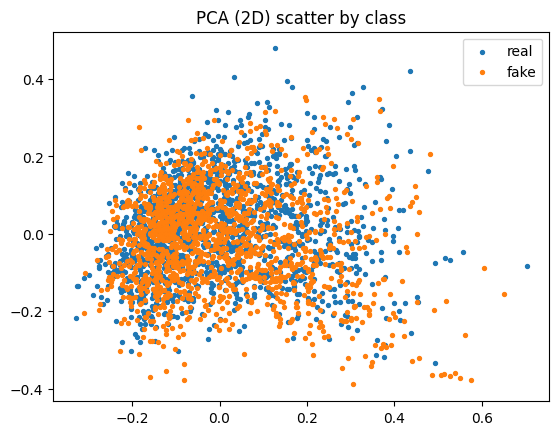

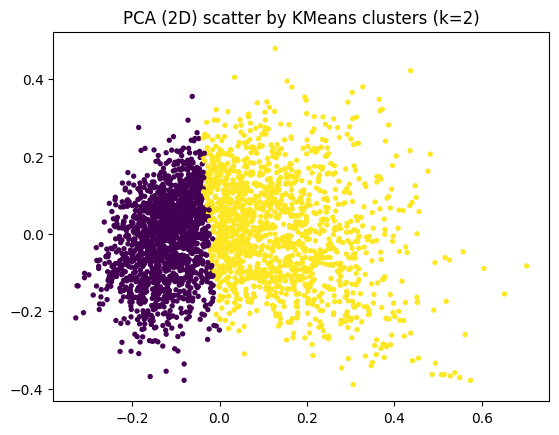

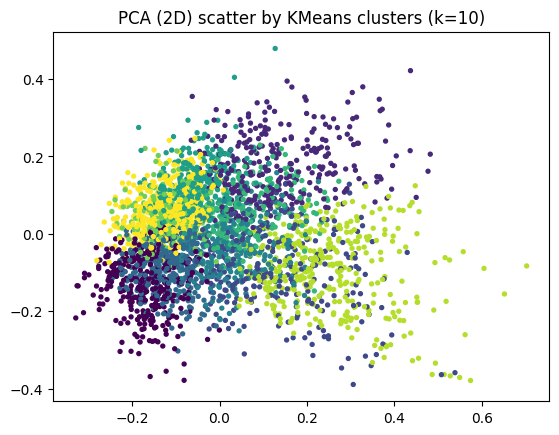

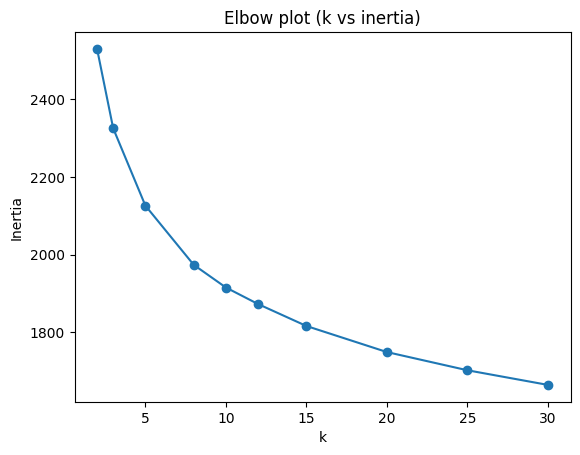

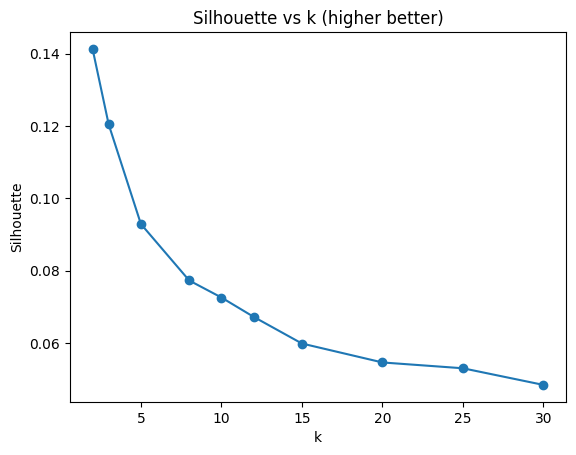

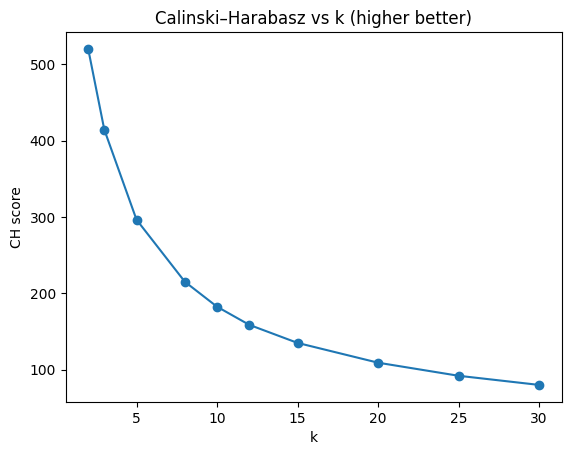

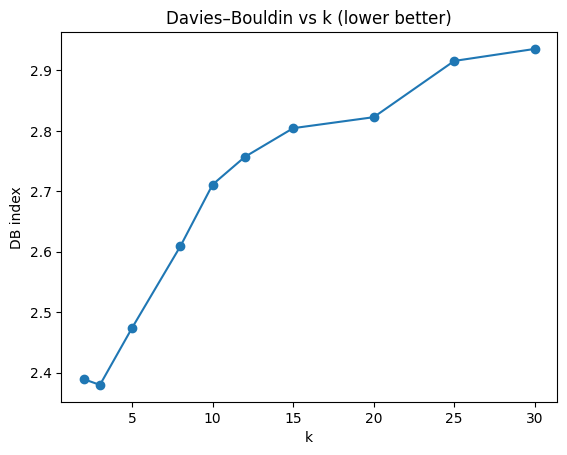


Cluster composition (k=2, sorted):


label,real,fake,total
cluster,,,
0,792,792,1584
1,708,708,1416


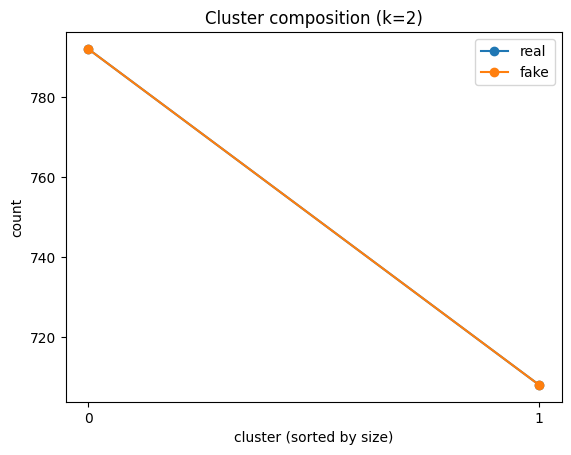


Fake technique counts (top clusters, k=2):


tech,stargan_tiles
cluster,
0,792
1,708


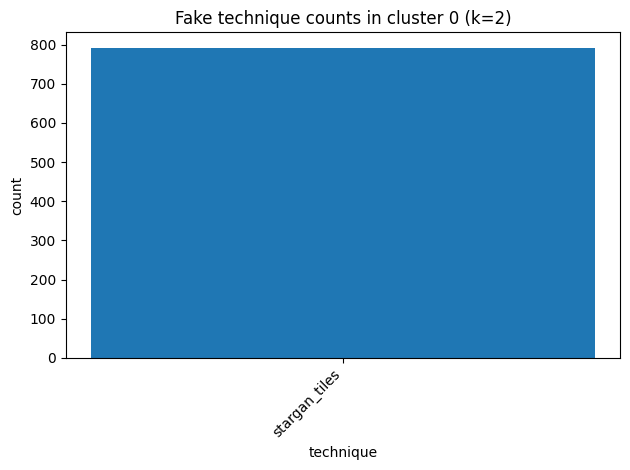

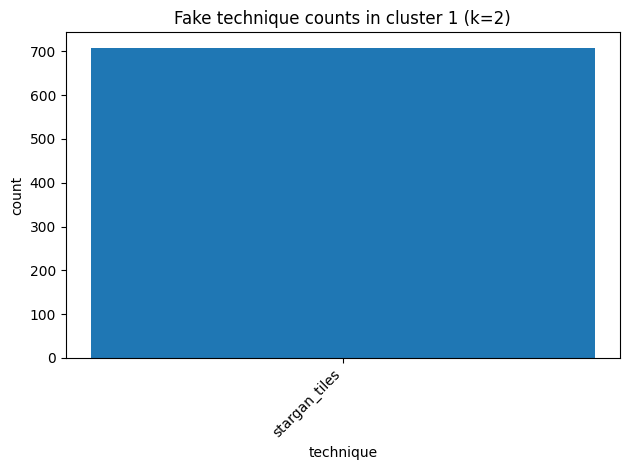


Cluster composition (k=10, sorted):


label,real,fake,total
cluster,,,
9,207,204,411
8,145,215,360
0,162,164,326
5,184,132,316
3,149,164,313
1,168,129,297
2,141,135,276
4,116,153,269
7,118,115,233


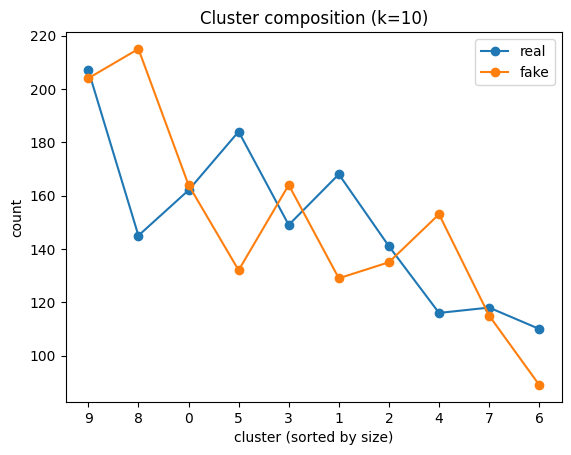


Fake technique counts (top clusters, k=10):


tech,stargan_tiles
cluster,
0,164
8,215
9,204


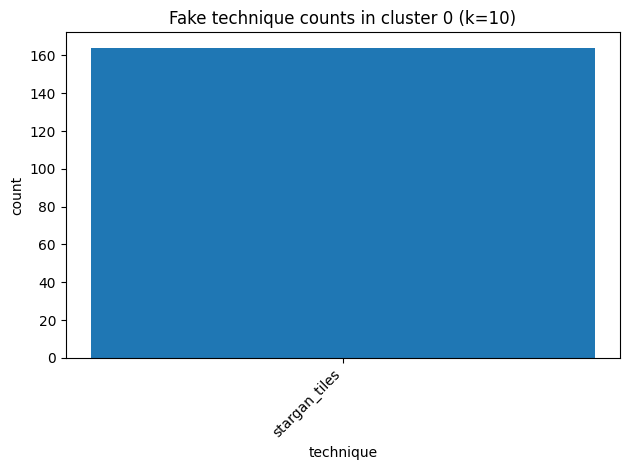

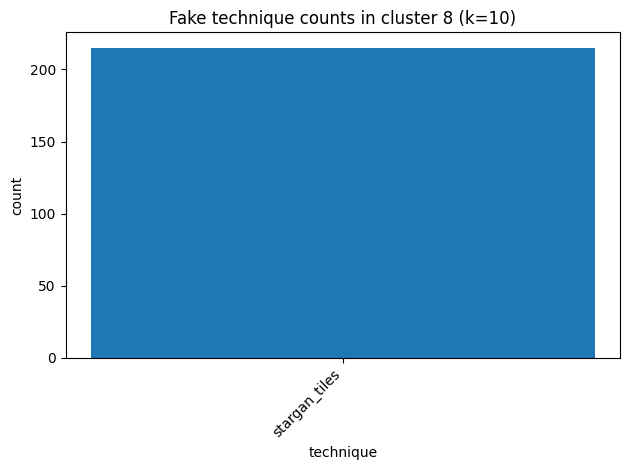

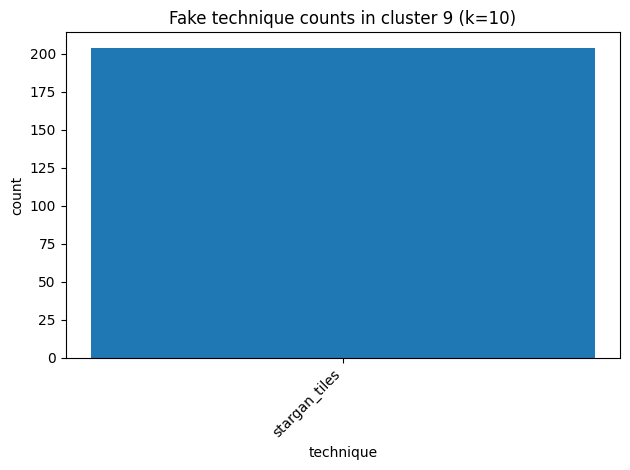

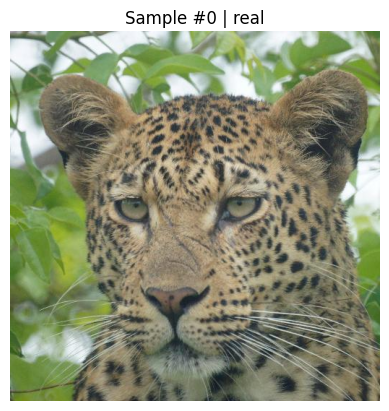

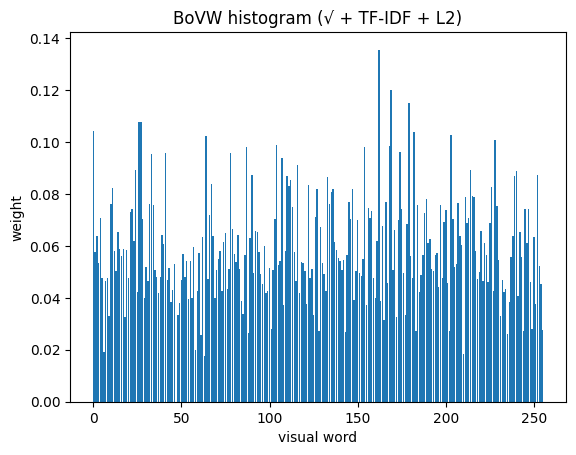

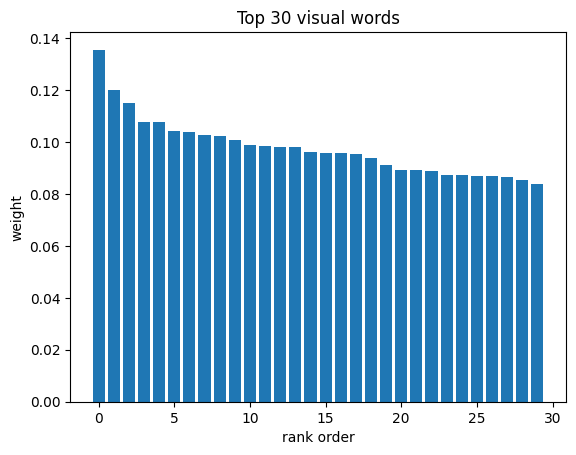

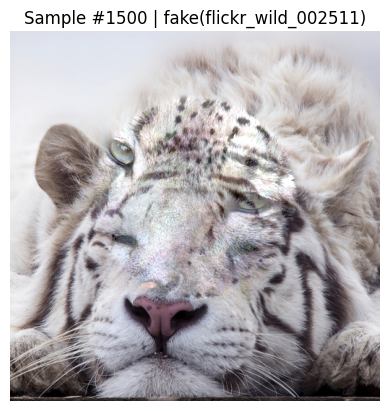

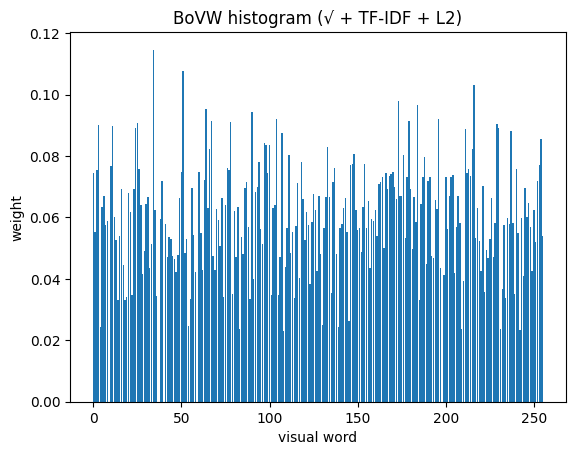

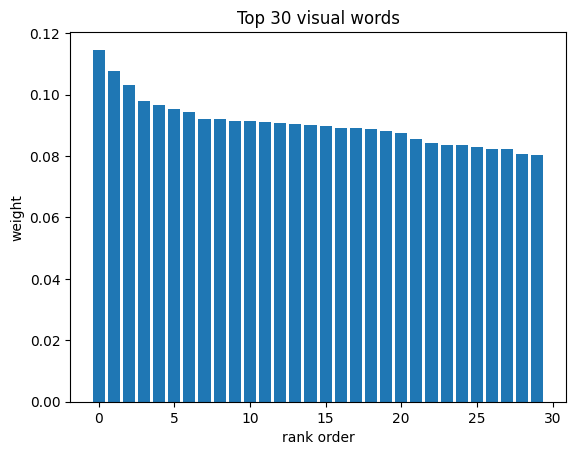


Done: generated K-Means EDA charts and BoVW visualizations (best-k and k=10).


In [7]:
# Don't run -- keep
# K-MEANS EDA + BoVW VIS (TRAIN SPLIT) — new setup + explicit k=10
# - Works with combined_balanced/train: real/{cat,dog,wild}, fake/<tech> (flat or nested)
# - Reuses artifacts in /content/stargan-v2/bovw when available (codebook K=128, PCA to 64)
# - BoVW pipeline matches training: sqrt(H) + TF-IDF + L2; clustering on L2-normalized PCA ("spherical")
# - Shows both best-k (by silhouette) and k=10 compositions/plots

import os, random, gc, math
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import normalize
from joblib import dump, load

# ---------------------------
# CONFIG (new setup)
# ---------------------------
random.seed(42); np.random.seed(42)

BASE           = Path("/content/stargan-v2")
TRAIN_ROOT     = BASE/"combined_balanced"/"train"
REAL_ROOT      = TRAIN_ROOT/"real"   # expects {cat,dog,wild}
FAKE_SOURCES = {
    "stargan_tiles": TRAIN_ROOT/"fake"/"stargan_tiles",
    "copy_move":     TRAIN_ROOT/"fake"/"copy_move",
    "inpaint":       TRAIN_ROOT/"fake"/"inpaint",
    "postproc":      TRAIN_ROOT/"fake"/"postproc",
    "splicing":      TRAIN_ROOT/"fake"/"splicing",
    "swap_like":     TRAIN_ROOT/"fake"/"swap_like",
}

OUT_DIR   = BASE/"bovw"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Sampling controls
MAX_PER_CLASS         = 1500     # per class (None = all)
RESIZE_MAX_SIDE       = 512
MAX_DESCS_PER_IMAGE   = 500
MAX_TOTAL_DESCRIPTORS = 200_000  # cap for codebook fitting

# Prefer to reuse your training artifacts if present
# (e.g., kmeans_codebook_SIFT_K128.joblib , pca_SIFT_K128_to64.joblib)
def pick_one(pattern: str):
    cands = list(OUT_DIR.glob(pattern))
    return cands[0] if cands else None

CODEBOOK_PATH = pick_one("kmeans_codebook_*_K*.joblib")  # try to reuse (K likely 128)
PCA_PATH      = pick_one("pca_*_K*_to*.joblib")          # try to reuse (to 64)

# If no artifacts found, we’ll fit a quick local codebook/PCA
DEFAULT_KWORDS   = 128
DEFAULT_PCA_DIMS = 64

# Clustering k-grid (evaluate a bit wider, and always include k=10)
K_LIST = [2,3,5,8,10,12,15,20,25,30]

# ---------------------------
# HELPERS
# ---------------------------
EXTS = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}

def list_images_recursive(root: Path):
    if not root.exists(): return []
    return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in EXTS]

def load_gray_resize(p: Path, max_side=RESIZE_MAX_SIDE):
    im = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if im is None: return None
    h,w = im.shape[:2]; s = max(h,w)
    if s > max_side:
        sc = max_side/float(s)
        im = cv2.resize(im, (int(w*sc), int(h*sc)), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(im, cv2.COLOR_BGR2GRAY)

def get_detector():
    try:
        return cv2.SIFT_create(), "SIFT", 128
    except Exception:
        return cv2.ORB_create(nfeatures=1000, fastThreshold=10), "ORB", 32

def extract_desc(detector, gray, desc_dim):
    kps, desc = detector.detectAndCompute(gray, None)
    if desc is None or len(kps)==0:
        return np.zeros((0, desc_dim), np.float32)
    if desc.dtype != np.float32: desc = desc.astype(np.float32)
    return desc

def parse_fake_tech(p: Path):
    s = p.stem
    return s.split("__")[-1] if "__" in s else "unknown"

# ---------------------------
# 1) Collect TRAIN sample (new layout)
# ---------------------------
# real: species subfolders
SPECIES = ["cat","dog","wild"]
real_paths = []
for sp in SPECIES:
    real_paths += list_images_recursive(REAL_ROOT/sp)

# fake: flat technique dirs (or nested; we recurse anyway)
fake_paths = []
fake_tech  = []
for tech, root in FAKE_SOURCES.items():
    ps = list_images_recursive(root)
    fake_paths += ps
    fake_tech  += [tech]*len(ps)

# sample per class
random.shuffle(real_paths); random.shuffle(fake_paths)
if MAX_PER_CLASS is not None:
    real_paths = real_paths[:MAX_PER_CLASS]
    fake_paths = fake_paths[:MAX_PER_CLASS]
    fake_tech  = fake_tech[:len(fake_paths)]

X_paths = real_paths + fake_paths
y       = np.array([0]*len(real_paths) + [1]*len(fake_paths), dtype=np.int64)
tech    = ["real"]*len(real_paths) + fake_tech

print(f"Sampled TRAIN: real={len(real_paths)} fake={len(fake_paths)} total={len(X_paths)}")
assert len(X_paths)>0, "No images found. Check combined_balanced/train paths."

# ---------------------------
# 2) Codebook (reuse if available; else fit quick)
# ---------------------------
det, det_name, desc_dim = get_detector()
print("Feature detector:", det_name)

codebook = None; KWORDS = DEFAULT_KWORDS
if CODEBOOK_PATH is not None:
    try:
        codebook = load(CODEBOOK_PATH)
        KWORDS = int(getattr(codebook, "n_clusters", DEFAULT_KWORDS))
        print("Loaded codebook:", CODEBOOK_PATH.name)
    except Exception:
        codebook = None

if codebook is None:
    print("Fitting visual codebook...")
    all_descs, total = [], 0
    for p in X_paths:
        g = load_gray_resize(p)
        if g is None: continue
        d = extract_desc(det, g, desc_dim)
        if d.shape[0]==0: continue
        if d.shape[0] > MAX_DESCS_PER_IMAGE:
            idx = np.random.choice(d.shape[0], MAX_DESCS_PER_IMAGE, replace=False)
            d = d[idx]
        all_descs.append(d)
        total += d.shape[0]
        if total >= MAX_TOTAL_DESCRIPTORS: break
    assert len(all_descs)>0, "No descriptors to fit codebook."
    D = np.vstack(all_descs).astype(np.float32)
    codebook = MiniBatchKMeans(n_clusters=KWORDS, batch_size=4096, random_state=42, reassignment_ratio=0.01)
    codebook.fit(D)
    # Don’t overwrite your main artifact; stash locally for EDA
    dump(codebook, OUT_DIR/f"eda_codebook_{det_name}_K{KWORDS}.joblib")
    del D, all_descs; gc.collect()
    print("Saved EDA codebook:", OUT_DIR/f"eda_codebook_{det_name}_K{KWORDS}.joblib")

# ---------------------------
# 3) BoVW histograms (√ + TF-IDF + L2)
# ---------------------------
def image_hist(p: Path):
    g = load_gray_resize(p)
    if g is None: return np.zeros((KWORDS,), np.float32)
    d = extract_desc(det, g, desc_dim)
    if d.shape[0]==0: return np.zeros((KWORDS,), np.float32)
    words = codebook.predict(d)
    return np.bincount(words, minlength=KWORDS).astype(np.float32)

H = np.zeros((len(X_paths), KWORDS), np.float32)
for i,p in enumerate(X_paths):
    H[i] = image_hist(p)
print("BoVW matrix:", H.shape)

# Power (Hellinger) + TF-IDF + L2 (match training)
H = np.sqrt(H, dtype=np.float32)
df = (H > 0).sum(axis=0)
idf = np.log((H.shape[0] + 1) / (df + 1)) + 1.0
H_tfidf = H * idf.reshape(1, -1)
H_norm  = normalize(H_tfidf, norm="l2")

# ---------------------------
# 4) PCA (reuse if available; else fit)
# ---------------------------
PCA_DIMS_CLUSTER = DEFAULT_PCA_DIMS   # 64
PCA_DIMS_PLOT    = 2

pca_cluster = None
if PCA_PATH is not None:
    try:
        pca_cluster = load(PCA_PATH)
        # Use whatever dims the artifact has (likely 64)
        PCA_DIMS_CLUSTER = int(getattr(pca_cluster, "n_components_", getattr(pca_cluster, "n_components", PCA_DIMS_CLUSTER)))
        print("Loaded PCA model:", Path(PCA_PATH).name, f"(dims={PCA_DIMS_CLUSTER})")
    except Exception:
        pca_cluster = None

if pca_cluster is None:
    pca_cluster = PCA(n_components=PCA_DIMS_CLUSTER, random_state=42)
    pca_cluster.fit(H_norm)
    dump(pca_cluster, OUT_DIR/f"eda_pca_to{PCA_DIMS_CLUSTER}.joblib")

X_cluster = pca_cluster.transform(H_norm)

# 2D PCA for scatter (fresh small PCA to 2)
pca_plot = PCA(n_components=PCA_DIMS_PLOT, random_state=42).fit(H_norm)
X_plot   = pca_plot.transform(H_norm)

# Spherical KMeans basis: L2-normalize PCA features
X_for_km = normalize(X_cluster, norm="l2")

print("PCA dims:", X_cluster.shape, X_plot.shape)

# ---------------------------
# 5) KMeans elbow + validity (on PCA-64)
# ---------------------------
inertias, sils, chs, dbs = [], [], [], []

SIL_MAX = 4000
if X_for_km.shape[0] > SIL_MAX:
    idx_sil = np.random.choice(X_for_km.shape[0], SIL_MAX, replace=False)
    X_sil = X_for_km[idx_sil]
else:
    X_sil = X_for_km

labels_by_k = {}
for k in K_LIST:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42).fit(X_for_km)
    labels_k = km.labels_
    labels_by_k[k] = (km, labels_k)
    inertias.append(km.inertia_)
    try: sil = silhouette_score(X_sil, km.predict(X_sil))
    except Exception: sil = np.nan
    try: ch  = calinski_harabasz_score(X_for_km, labels_k)
    except Exception: ch  = np.nan
    try: db  = davies_bouldin_score(X_for_km, labels_k)
    except Exception: db  = np.nan
    sils.append(sil); chs.append(ch); dbs.append(db)

# pick best k by silhouette; also force k=10
s_arr = np.array(sils, dtype=np.float64)
k_best = K_LIST[int(np.nanargmax(s_arr))] if np.any(~np.isnan(s_arr)) else 2
km_best, clusters_best = labels_by_k[k_best]
km_k10,  clusters_k10  = labels_by_k[10] if 10 in labels_by_k else (KMeans(n_clusters=10, n_init="auto", random_state=42).fit(X_for_km), None)
if clusters_k10 is None:
    clusters_k10 = km_k10.labels_

print(f"[SELECT] best k by silhouette = {k_best}  | also evaluating k=10")

# ---------------------------
# 6) CHARTS (matplotlib, one per figure, no explicit colors)
# ---------------------------
plt.figure()
plt.scatter(X_plot[y==0,0], X_plot[y==0,1], s=8, label="real")
plt.scatter(X_plot[y==1,0], X_plot[y==1,1], s=8, label="fake")
plt.title("PCA (2D) scatter by class")
plt.legend(); plt.show()

plt.figure()
plt.scatter(X_plot[:,0], X_plot[:,1], s=8, c=clusters_best)
plt.title(f"PCA (2D) scatter by KMeans clusters (k={k_best})")
plt.show()

plt.figure()
plt.scatter(X_plot[:,0], X_plot[:,1], s=8, c=clusters_k10)
plt.title("PCA (2D) scatter by KMeans clusters (k=10)")
plt.show()

plt.figure()
plt.plot(K_LIST, inertias, marker='o')
plt.title("Elbow plot (k vs inertia)")
plt.xlabel("k"); plt.ylabel("Inertia"); plt.show()

plt.figure()
plt.plot(K_LIST, sils, marker='o')
plt.title("Silhouette vs k (higher better)")
plt.xlabel("k"); plt.ylabel("Silhouette"); plt.show()

plt.figure()
plt.plot(K_LIST, chs, marker='o')
plt.title("Calinski–Harabasz vs k (higher better)")
plt.xlabel("k"); plt.ylabel("CH score"); plt.show()

plt.figure()
plt.plot(K_LIST, dbs, marker='o')
plt.title("Davies–Bouldin vs k (lower better)")
plt.xlabel("k"); plt.ylabel("DB index"); plt.show()

# ---------------------------
# 7) Cluster composition & fake-tech preference (best-k & k=10)
# ---------------------------
def comp_and_plots(clusters, k_val, title_suffix=""):
    df_local = pd.DataFrame({
        "path": [str(p) for p in X_paths],
        "label": y,
        "cluster": clusters,
        "tech": tech
    })
    comp = df_local.groupby(["cluster","label"]).size().unstack(fill_value=0).rename(columns={0:"real",1:"fake"})
    comp["total"] = comp.sum(axis=1)
    comp = comp.sort_values("total", ascending=False)
    print(f"\nCluster composition (k={k_val}, sorted):")
    try:
        from IPython.display import display as _display
        _display(comp)
    except Exception:
        print(comp.head(20))

    plt.figure()
    x = np.arange(len(comp.index))
    plt.plot(x, comp["real"].values, marker='o', label="real")
    plt.plot(x, comp["fake"].values, marker='o', label="fake")
    plt.title(f"Cluster composition (k={k_val})")
    plt.xlabel("cluster (sorted by size)"); plt.ylabel("count")
    plt.xticks(x, comp.index.astype(str))
    plt.legend(); plt.show()

    # fake-tech preference (top 3 clusters by size)
    tech_counts = (df_local[df_local["label"]==1].groupby(["cluster","tech"]).size().unstack(fill_value=0))
    tech_counts = tech_counts.loc[tech_counts.index.intersection(comp.index[:3])]
    print(f"\nFake technique counts (top clusters, k={k_val}):")
    try:
        _display(tech_counts)
    except Exception:
        print(tech_counts.head())

    for cl in tech_counts.index:
        row = tech_counts.loc[cl]
        plt.figure()
        plt.bar(range(len(row.index)), row.values)
        plt.title(f"Fake technique counts in cluster {cl} (k={k_val})")
        plt.xlabel("technique"); plt.ylabel("count")
        plt.xticks(range(len(row.index)), row.index, rotation=45, ha='right')
        plt.tight_layout(); plt.show()

    # Save CSVs for convenience
    comp.to_csv(OUT_DIR/f"eda_clusters_k{k_val}_sample_composition.csv")
    tech_counts.to_csv(OUT_DIR/f"eda_clusters_k{k_val}_sample_tech_counts.csv")

comp_and_plots(clusters_best, k_best)
comp_and_plots(clusters_k10, 10)

# ---------------------------
# 8) Visualize: IMAGE → BoVW histogram (same normalization)
# ---------------------------
def visualize_bovw(idx):
    p = X_paths[idx]
    lab = "fake("+parse_fake_tech(p)+")" if y[idx]==1 else "real"
    im = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if im is not None:
        plt.figure()
        plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        plt.title(f"Sample #{idx} | {lab}")
        plt.axis('off'); plt.show()
    # Full histogram
    plt.figure()
    plt.bar(np.arange(KWORDS), H_norm[idx])
    plt.title("BoVW histogram (√ + TF-IDF + L2)"); plt.xlabel("visual word"); plt.ylabel("weight")
    plt.show()
    # Top 30 words
    topk = 30
    inds = np.argsort(-H_norm[idx])[:topk]
    vals = H_norm[idx][inds]
    plt.figure()
    plt.bar(np.arange(topk), vals)
    plt.title("Top 30 visual words"); plt.xlabel("rank order"); plt.ylabel("weight")
    plt.show()

# show one real and one fake
if np.any(y==0): visualize_bovw(int(np.where(y==0)[0][0]))
if np.any(y==1): visualize_bovw(int(np.where(y==1)[0][0]))

print("\nDone: generated K-Means EDA charts and BoVW visualizations (best-k and k=10).")


In [5]:
# === TEST features: apply TRAIN BoVW, PCA, and TEST KMeans (k=2 & k=10)
# Output CSV has the SAME columns as train/image_features.csv

import os, re, gc, glob, json, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans

# -------------------
# Paths / Config
# -------------------
BASE         = Path("/content/stargan-v2")
TEST_ROOT    = BASE/"combined_balanced"/"test"  # {real,fake}
REAL_SRC     = TEST_ROOT/"real"                 # {cat,dog,wild}
FAKE_SOURCES = {
    "stargan_tiles": TEST_ROOT/"fake"/"stargan_tiles",
    "copy_move":     TEST_ROOT/"fake"/"copy_move",
    "inpaint":       TEST_ROOT/"fake"/"inpaint",
    "postproc":      TEST_ROOT/"fake"/"postproc",
    "splicing":      TEST_ROOT/"fake"/"splicing",
    "swap_like":     TEST_ROOT/"fake"/"swap_like",
}
ARTIFACTS    = BASE/"bovw"                      # where TRAIN saved artifacts
OUT_DIR      = ARTIFACTS
OUT_DIR.mkdir(parents=True, exist_ok=True)

EXTS     = {".jpg",".jpeg",".png",".bmp",".webp",".tif",".tiff"}
MAX_SIDE = 512
RNG      = 42
np.random.seed(RNG)

# Choose which TEST cluster to mark as "best" (to mirror train)
KM_K_BEST = 2
KM_K10    = 10
KM_K50    = 50 # Added 50 clusters

# -------------------
# Load TRAIN artifacts
# -------------------
def _pick_artifacts(dirpath: Path):
    km_files  = sorted(glob.glob(str(dirpath/"kmeans_*_K*.joblib")))
    pca_files = sorted(glob.glob(str(dirpath/"pca_*_K*_to*.joblib")))
    if not km_files or not pca_files:
        raise FileNotFoundError(f"Missing TRAIN artifacts in {dirpath}")
    def parse_k(f):
        m = re.search(r"_K(\d+)", Path(f).stem);
        return int(m.group(1)) if m else None

    km_by_k  = {parse_k(f): f for f in km_files}
    pca_by_k = {parse_k(f): f for f in pca_files}
    Ks = sorted(set(km_by_k.keys()) & set(pca_by_k.keys()))
    if Ks:
        Ksel = max(Ks)
        km_path, pca_path = km_by_k[Ksel], pca_by_k[Ksel]
    else:
        km_path, pca_path = km_files[0], pca_files[0]

    det = "SIFT" if "SIFT" in Path(km_path).name else ("ORB" if "ORB" in Path(km_path).name else "DET")
    # Optional IDF (if you saved it during train). If absent, we’ll skip TF-IDF.
    idf = None
    idf_cands = list(dirpath.glob(f"idf_{det}_K*.npy"))
    if idf_cands:
        idf_by_k = {parse_k(str(p)): p for p in idf_cands}
        K_used   = parse_k(km_path)
        idf = np.load(idf_by_k.get(K_used, idf_cands[0]))

    m_dims = re.search(r"_to(\d+)", Path(pca_path).stem)
    pca_dims = int(m_dims.group(1)) if m_dims else None
    return km_path, pca_path, det, pca_dims, idf

KM_PATH, PCA_PATH, DET_TAG, PCA_DIMS, IDF_VEC = _pick_artifacts(ARTIFACTS)
codebook = joblib.load(KM_PATH)     # MiniBatchKMeans (visual words)
pca      = joblib.load(PCA_PATH)    # PCA trained on TRAIN

def load_kmeans_model_k(dirpath: Path, k: int):
  pattern = f"km_img_model_k{k}.joblib"
  cands = list(dirpath.glob(pattern))
  if not cands:
    raise FileNotFoundError(f"No KMeans model for k={k} found matching {pattern} in {dirpath}")
  return joblib.load(cands[0])

km_model_k2 = load_kmeans_model_k(ARTIFACTS, 2)
km_model_k10 = load_kmeans_model_k(ARTIFACTS, 10)
km_model_k50 = load_kmeans_model_k(ARTIFACTS, 50)

KWORDS   = int(re.search(r"_K(\d+)", Path(KM_PATH).stem).group(1))
print(f"Loaded: {Path(KM_PATH).name}, {Path(PCA_PATH).name} | K={KWORDS} | PCA D={PCA_DIMS} | TF-IDF={'Yes' if IDF_VEC is not None else 'No'}")


# -------------------
# Helpers
# -------------------
def list_images_recursive(root: Path):
    if not root.exists(): return []
    return [p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in EXTS]

def load_gray_resize_for_desc(p: Path):
    img = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if img is None: return None
    h, w = img.shape[:2]
    s = max(h, w)
    if s > MAX_SIDE:
        sc = MAX_SIDE / float(s)
        img = cv2.resize(img, (int(w*sc), int(h*sc)), interpolation=cv2.INTER_AREA)
    return cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def pre_stats_for_path(p: Path):
    try:
        file_size = int(p.stat().st_size)
    except Exception:
        file_size = np.nan
    bgr = cv2.imread(str(p), cv2.IMREAD_COLOR)
    if bgr is None:
        return dict(width=-1, height=-1, aspect_ratio=np.nan,
                    brightness=np.nan, contrast=np.nan, sharpness_l1_mean=np.nan,
                    file_size=file_size)
    h, w = bgr.shape[:2]
    g = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    gx = cv2.Sobel(g, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(g, cv2.CV_32F, 0, 1, ksize=3)

    # Added -- edge density (Canny) + Laplacian variance blur
    edges = cv2.Canny(g, 100, 200)
    edge_density = float((edges > 0).mean())
    lap = cv2.Laplacian(g, cv2.CV_64F)
    lap_var = float(lap.var())

    return dict(
        width=int(w), height=int(h),
        aspect_ratio=(w/float(h) if h>0 else np.nan),
        brightness=float(g.mean()),
        contrast=float(g.std()),
        sharpness_l1_mean=float(np.mean(np.abs(gx)) + np.mean(np.abs(gy))),
        edge_density=edge_density, # New
        lap_var=lap_var,           # New
        file_size=file_size        # New
    )

def get_detector():
    try:
        sift = cv2.SIFT_create()
        return sift, 128
    except Exception:
        orb = cv2.ORB_create(nfeatures=1000, fastThreshold=10)
        return orb, 32

def extract_desc(det, gray, ddim):
    kps, desc = det.detectAndCompute(gray, None)
    if desc is None or len(kps)==0:
        return np.zeros((0, ddim), np.float32)
    return desc.astype(np.float32) if desc.dtype != np.float32 else desc

def image_hist(p: Path, det, ddim):
    gray = load_gray_resize_for_desc(p)
    if gray is None:
        return np.zeros((KWORDS,), np.float32)
    desc = extract_desc(det, gray, ddim)
    if desc.shape[0]==0:
        return np.zeros((KWORDS,), np.float32)
    words = codebook.predict(desc)
    return np.bincount(words, minlength=KWORDS).astype(np.float32)

def normalize_bovw_like_train(H, idf=None):
    # Match your training normalization: sqrt -> (optional TF-IDF) -> L2
    H = np.sqrt(H, dtype=np.float32)
    if idf is not None:
        H = H * idf.reshape(1, -1)
    H = normalize(H, norm="l2")
    return H

def kmeans_soft_membership(km, X, eps=1e-12):
  dists = km.transform(X)
  inv = 1.0 / (dists + eps)
  inv_sum = inv.sum(axis=1, keepdims=True) + eps
  probs = inv / inv_sum
  return probs.astype(np.float32)

# -------------------
# Collect TEST paths/labels + metadata
# -------------------
SPECIES = ["cat","dog","wild"]
real_paths = []
for sp in SPECIES:
    real_paths += list_images_recursive(REAL_SRC/sp)

fake_paths, fake_techniques = [], []
for tech, root in FAKE_SOURCES.items():
    ps = list_images_recursive(root)
    fake_paths += ps
    fake_techniques += [tech]*len(ps)

paths  = real_paths + fake_paths
labels = [0]*len(real_paths) + [1]*len(fake_paths)
label_names = ["real"]*len(real_paths) + ["fake"]*len(fake_paths)

# species (real from folder; fake often unknown for flat layout)
species = []
for p, lab in zip(paths, labels):
    if lab == 0:
        # infer species from path (cat/dog/wild)
        sp = "unknown"
        parts = [pp.lower() for pp in p.parts]
        for s in SPECIES:
            if s in parts:
                sp = s; break
        species.append(sp)
    else:
        species.append("unknown")

fake_technique = ["none"]*len(real_paths) + fake_techniques

print(f"TEST: real={len(real_paths)} fake={len(fake_paths)} total={len(paths)}")
assert len(paths) > 0, f"No images found in {TEST_ROOT}"

# -------------------
# Compute pre-stats + BoVW -> PCA (TRAIN)
# -------------------
det, desc_dim = get_detector()

# pre-stats
rows = []
print("Computing pre-stats...")
for p, lab in tqdm(list(zip(paths, labels)), total=len(paths)):
    st = pre_stats_for_path(p)
    st["path"] = str(p); st["label"] = int(lab); st["label_name"] = ("real" if lab==0 else "fake")
    rows.append(st)
df = pd.DataFrame(rows)

# BoVW
print("Building BoVW histograms...")
H = np.zeros((len(paths), KWORDS), np.float32)
for i, p in enumerate(tqdm(paths)):
    H[i] = image_hist(p, det, desc_dim)

H_norm = normalize_bovw_like_train(H, idf=IDF_VEC)

# PCA (apply TRAIN)
print("Applying TRAIN PCA...")
X_pca = pca.transform(H_norm)
assert X_pca.shape[1] == (PCA_DIMS or X_pca.shape[1]), "PCA dims mismatch"

# -------------------
# KMeans on TEST PCA (k=2 == km_k_best, and k=10)
# -------------------
from sklearn.preprocessing import normalize as l2norm
X_for_km = l2norm(X_pca, norm="l2")  # spherical

print("Applying TRAIN KMeans models (k=2,10,50) to TEST PCA...")
labs_best = km_model_k2.predict(X_for_km)
labs_k10 = km_model_k10.predict(X_for_km)
labs_k50 = km_model_k50.predict(X_for_km)

prob_k2 = kmeans_soft_membership(km_model_k2, X_for_km)
prob_k10 = kmeans_soft_membership(km_model_k10, X_for_km)
prob_k50 = kmeans_soft_membership(km_model_k50, X_for_km)

np.save(OUT_DIR/"km_img_labels_k2_test.npy",  labs_best)
np.save(OUT_DIR/"km_img_labels_k10_test.npy", labs_k10)
np.save(OUT_DIR/"km_img_labels_k50_test.npy", labs_k50)

# -------------------
# Build CSV with the SAME columns as train/image_features.csv
# -------------------
# header (same order)
base_cols = [
    "path","label","label_name","species","fake_technique",
    "width","height","aspect_ratio","brightness","contrast","sharpness_l1_mean",
    "edge_density", "lap_var", "file_size", # New
    "bovw_K","pca_dims","km_k_best","km_label_best","km_label_k10", "km_label_k50" # New
]

data = {
    "path": df["path"].values,
    "label": df["label"].values,
    "label_name": df["label_name"].values,
    "species": np.array(species, dtype=object),
    "fake_technique": np.array(fake_technique, dtype=object),
    "width": df["width"].values,
    "height": df["height"].values,
    "aspect_ratio": df["aspect_ratio"].values,
    "brightness": df["brightness"].values,
    "contrast": df["contrast"].values,
    "sharpness_l1_mean": df["sharpness_l1_mean"].values,
    "edge_density": df["edge_density"].values, # New
    "lap_var": df["lap_var"].values, # New
    "file_size": df["file_size"].values,
    "bovw_K": np.full((len(paths),), KWORDS, dtype=np.int32),
    "pca_dims": np.full((len(paths),), X_pca.shape[1], dtype=np.int32),
    "km_k_best": np.full((len(paths),), KM_K_BEST, dtype=np.int32),
    "km_label_best": labs_best.astype(np.int32),
    "km_label_k10":  labs_k10.astype(np.int32),
    "km_label_k50": labs_k50.astype(np.int32) # New
}

# New
for j in range(prob_k2.shape[1]):
  data[f"prob_k2_{j}"] = prob_k2[:, j]

for j in range(prob_k10.shape[1]):
  data[f"prob_k10_{j}"] = prob_k10[:, j]

for j in range(prob_k50.shape[1]):
  data[f"prob_k50_{j}"] = prob_k50[:, j]

# add BoVW columns (bovw_0..bovw_{K-1})
for j in range(KWORDS):
    data[f"bovw_{j}"] = H_norm[:, j]

# add PCA columns (pca_0..pca_{D-1})
D = X_pca.shape[1]
for j in range(D):
    data[f"pca_{j}"] = X_pca[:, j]

df_out = pd.DataFrame(
    data,
    columns=base_cols
      + [f"prob_k2_{j}" for j in range(prob_k2.shape[1])]
      + [f"prob_k10_{j}" for j in range(prob_k10.shape[1])]
      + [f"prob_k50_{j}" for j in range(prob_k50.shape[1])]
      + [f"bovw_{j}" for j in range(KWORDS)]
      + [f"pca_{j}" for j in range(D)])
csv_path = OUT_DIR/"image_features_test.csv"
df_out.to_csv(csv_path, index=False)

# Save arrays too, if you want parity with train artifacts
np.save(OUT_DIR/f"H_{DET_TAG}_K{KWORDS}_test.npy", H_norm)
np.save(OUT_DIR/f"X_pca_{DET_TAG}_K{KWORDS}_test.npy", X_pca)
np.save(OUT_DIR/"y_test.npy", np.array(labels, dtype=np.int64))

print(f"\nWrote: {csv_path}")
print(f"Rows: {len(df_out)} | Cols: {df_out.shape[1]}  (K={KWORDS}, PCA={D})")
print("Done.")


Loaded: kmeans_codebook_SIFT_K256.joblib, pca_SIFT_K256_to64.joblib | K=256 | PCA D=64 | TF-IDF=No
TEST: real=5760 fake=5760 total=11520
Computing pre-stats...


100%|██████████| 11520/11520 [03:27<00:00, 55.44it/s]


Building BoVW histograms...


100%|██████████| 11520/11520 [28:04<00:00,  6.84it/s]


Applying TRAIN PCA...
Applying TRAIN KMeans models (k=2,10,50) to TEST PCA...

Wrote: /content/stargan-v2/bovw/image_features_test.csv
Rows: 11520 | Cols: 402  (K=256, PCA=64)
Done.


In [6]:
import os, shutil
src = "/content/stargan-v2/bovw"
dst = "/content/drive/MyDrive/deepfake_project/output/bovw3"

os.makedirs(os.path.dirname(dst), exist_ok=True)

# If a previous folder exists, remove it (optional)
if os.path.exists(dst):
    shutil.rmtree(dst)

# Copy the whole directory tree
shutil.copytree(src, dst)
print("Copied to:", dst)


Copied to: /content/drive/MyDrive/deepfake_project/output/bovw3


In [7]:
# === Zip StarGAN-v2 'data' folder and move to Drive ===
from pathlib import Path
from datetime import datetime
import shutil, sys

SRC = Path("/content/stargan-v2/bovw")
DEST_DIR = Path("/content/drive/MyDrive/deepfake_project/output/bovw3")

# Safety checks
if not SRC.exists():
    raise FileNotFoundError(f"Source folder not found: {SRC}")
if not any(SRC.rglob("*")):
    raise RuntimeError(f"Source folder is empty: {SRC}")

DEST_DIR.mkdir(parents=True, exist_ok=True)

# Timestamped archive name
stamp = datetime.now().strftime("%Y%m%d-%H%M%S")
archive_base = Path(f"/content/stargan-v2_data_bovw_kmeans_pca-{stamp}")  # no extension for make_archive

print(f"Creating ZIP archive from: {SRC}")
# Create ZIP (you can switch 'zip' -> 'gztar' for .tar.gz if preferred)
zip_path_str = shutil.make_archive(
    base_name=str(archive_base),
    format="zip",
    root_dir=SRC.parent,   # /content/stargan-v2
    base_dir=SRC.name      # data
)
archive_path = Path(zip_path_str)

# Move to Drive
final_path = DEST_DIR / archive_path.name
print(f"Moving archive to: {final_path}")
shutil.move(str(archive_path), str(final_path))

# Report
size_gb = final_path.stat().st_size / (1024**3)
print(f"✅ Archive ready: {final_path}")
print(f"   Size: {size_gb:.2f} GB")


Creating ZIP archive from: /content/stargan-v2/bovw
Moving archive to: /content/drive/MyDrive/deepfake_project/output/bovw3/stargan-v2_data_bovw_kmeans_pca-20251214-124333.zip
✅ Archive ready: /content/drive/MyDrive/deepfake_project/output/bovw3/stargan-v2_data_bovw_kmeans_pca-20251214-124333.zip
   Size: 4.18 GB


In [8]:
print("done")

done


In [9]:
print("done")

done


In [10]:
print("done")

done
